# ICU Mortality Prediction Using Machine Learning  

**Course:** CS 4082 Machine Learning

**Team Members:** Sarah Elshiaty · Mashael Saeed · Seifeldin Elshiaty

## Project Objective

The objective of this project is to develop a machine learning model that predicts ICU patient mortality risk using structured clinical data.

This project combines data science analysis with machine learning methodology through:

- cleaning and preparing healthcare data  
- performing exploratory data analysis (EDA)  
- comparing multiple classification models  
- handling class imbalance  
- reducing noisy or less useful features  
- tuning prediction thresholds  
- interpreting outputs using risk groups and feature importance  

The final goal is to support earlier identification of high-risk ICU patients and provide interpretable decision-support insights.

## Notebook Symbols Guide

- ⭐ = Final selected experiment / final workflow steps  
- 🔴🟠🟡🟢🔵🟣⚪⚫🟤 = Experiment 1 sections  
- 🟥🟧🟨🟩🟦🟪 = Experiment 2 sections  
- ➕ = Extra supporting step / optional output  
- ❗ = Conclusion / practical summary  
- ⚠ = Transition to the next experiment or important note

These symbols are used to organize the notebook and distinguish each experimental stage clearly.


# ⭐ **Step 1: Problem Definition**

**The goal of this project is to estimate the mortality risk of ICU patients using structured clinical data.**

**We aim to answer:**
- *Can we identify patients who are at high risk of mortality using available features?*
- *Which clinical features contribute most to increased patient risk?*

Instead of only predicting whether a patient will survive or die, this project focuses on estimating risk levels to support early intervention and prioritization of care in ICU settings.

**This is a supervised classification problem where:**
- *Input: Patient features (demographics, vital signs, laboratory values, treatments, severity scores)*
- *Output: mortality_label (0 = survived, 1 = died), used to estimate risk probability*

# ⭐ **Step 2: Dataset**

*The dataset used is ICU Patient Monitoring and Mortality Prediction.*

- Number of samples: 15,000 patients
- Number of features: 24
- Target variable: mortality_label (0 = survived, 1 = died)

*The dataset includes:*
- Demographics (age, gender)
- Vital signs (heart rate, blood pressure, respiratory rate)
- Lab values (lactate, glucose)
- Clinical scores (APACHE, SOFA)
- Treatment indicators (ventilation, vasopressor)

## **2.1: Get Data / Load Dataset**

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np

# Load dataset (upload your CSV to Colab first)
from google.colab import files
uploaded = files.upload()

# Read dataset
data = pd.read_csv("ICU_Patient_Monitoring_Mortality_Prediction_15000.csv")

# Display first rows
data.head()

Saving ICU_Patient_Monitoring_Mortality_Prediction_15000.csv to ICU_Patient_Monitoring_Mortality_Prediction_15000.csv


,patient_id,age,gender,admission_type,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
0,PAT000001,32,Male,Urgent,3.75,136.06,19.64,162.01,127.16,104.04,...,73.71,7.77,4245.99,0,0,6.32,15.65,10.50,0,0
1,PAT000002,46,Male,Urgent,2.91,108.95,7.79,124.18,94.79,131.05,...,78.36,5.06,1267.36,0,1,29.00,33.29,6.09,0,1
2,PAT000003,87,Male,Urgent,6.84,95.21,7.44,117.54,89.35,171.84,...,168.41,1.89,4863.13,1,1,26.95,25.93,18.44,0,1
3,PAT000004,21,Male,Emergency,1.96,63.62,11.51,82.22,51.84,164.59,...,214.40,1.06,4940.99,1,0,1.16,33.54,14.14,0,1
4,PAT000005,21,Male,Urgent,7.71,65.92,12.17,74.98,39.34,146.10,...,201.33,5.28,4492.46,0,0,21.68,31.63,11.23,0,0


## **2.2: Understand the Data**

In [ ]:
# Shape of dataset
print("Shape of dataset:", data.shape)

# Column names
print("\nColumns:")
print(data.columns)

# Data types
print("\nData Types:")
print(data.dtypes)

# Summary statistics
data.describe()

Shape of dataset: (15000, 24)

Columns:
Index(['patient_id', 'age', 'gender', 'admission_type', 'comorbidity_score',
       'heart_rate_mean', 'heart_rate_std', 'heart_rate_max', 'heart_rate_min',
       'systolic_bp_mean', 'systolic_bp_std', 'respiratory_rate_mean',
       'spo2_mean', 'temperature_mean', 'glucose_mean', 'lactate_mean',
       'urine_output_total', 'ventilation_required', 'vasopressor_used',
       'length_of_stay_days', 'apache_score', 'sofa_score', 'sepsis_flag',
       'mortality_label'],
      dtype='object')

Data Types:
patient_id                object
age                        int64
gender                    object
admission_type            object
comorbidity_score        float64
heart_rate_mean          float64
heart_rate_std           float64
heart_rate_max           float64
heart_rate_min           float64
systolic_bp_mean         float64
systolic_bp_std          float64
respiratory_rate_mean    float64
spo2_mean                float64
temperature_mean     

,age,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,systolic_bp_std,respiratory_rate_mean,spo2_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,53.987533,4.988851,100.026900,15.087800,122.477551,82.523059,134.780335,12.539299,23.612935,90.051769,...,159.115675,4.270719,2760.416425,0.302200,0.245133,15.432166,22.496783,9.982515,0.201933,0.227867
std,21.027881,2.896171,23.187937,5.780114,25.304740,24.393954,25.982344,4.327404,6.654296,5.750619,...,51.867736,2.154312,1297.457979,0.459227,0.430181,8.368326,10.087201,5.747374,0.401456,0.419470
min,18.000000,0.000000,60.000000,5.000000,65.260000,30.600000,90.010000,5.000000,12.000000,80.000000,...,70.010000,0.500000,500.030000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000
25%,36.000000,2.420000,80.027500,10.077500,102.430000,62.207500,112.187500,8.780000,17.880000,85.080000,...,114.430000,2.420000,1636.355000,0.000000,0.000000,8.140000,13.640000,4.967500,0.000000,0.000000
50%,54.000000,4.980000,99.925000,15.180000,122.450000,82.575000,134.555000,12.570000,23.650000,90.020000,...,158.615000,4.290000,2767.555000,0.000000,0.000000,15.470000,22.635000,10.040000,0.000000,0.000000
75%,72.000000,7.540000,120.160000,20.080000,142.465000,102.842500,157.370000,16.260000,29.400000,95.000000,...,203.870000,6.120000,3887.780000,1.000000,0.000000,22.670000,31.140000,14.930000,0.000000,0.000000
max,90.000000,10.000000,140.000000,25.000000,179.320000,134.330000,180.000000,20.000000,35.000000,100.000000,...,249.980000,8.000000,4999.540000,1.000000,1.000000,30.000000,40.000000,20.000000,1.000000,1.000000


**This helps us understand:**

* *Number of rows and columns*
* *Type of each feature (numeric, categorical)*
* *Statistical range (mean, min, max)*

## **2.3: Clean / Prepare Data**
### **Data Cleaning**

*The dataset was checked for:*
- Missing values
- Data types
- Duplicates

No major cleaning was required, but preprocessing steps were applied for analysis.

In [ ]:
# Check missing values
print("Missing values:\n", data.isnull().sum())

# Check duplicates
print("\nDuplicate rows:", data.duplicated().sum())

# Remove duplicates if any
data = data.drop_duplicates()

# Drop unnecessary column (ID)
data = data.drop(columns=["patient_id"])

print("\nFinal shape after cleaning:", data.shape)

Missing values:
 patient_id               0
age                      0
gender                   0
admission_type           0
comorbidity_score        0
heart_rate_mean          0
heart_rate_std           0
heart_rate_max           0
heart_rate_min           0
systolic_bp_mean         0
systolic_bp_std          0
respiratory_rate_mean    0
spo2_mean                0
temperature_mean         0
glucose_mean             0
lactate_mean             0
urine_output_total       0
ventilation_required     0
vasopressor_used         0
length_of_stay_days      0
apache_score             0
sofa_score               0
sepsis_flag              0
mortality_label          0
dtype: int64

Duplicate rows: 0

Final shape after cleaning: (15000, 23)


1. *No missing values → dataset is clean*
2. *Remove duplicates → avoid bias*
3. *Remove patient_id → not useful for prediction*

## Experimental Design Overview

Three experiments were conducted to progressively improve model quality:

- **Experiment 1:** Baseline model using a cleaned broad feature set of **22 predictors**.  
  (The original raw dataset contained 24 columns, but identifier/non-predictive fields were excluded during preprocessing.)

- **Experiment 2:** Reduced-feature experiment using selected important predictors to test whether a smaller feature set could preserve performance.

- **Experiment 3:** Final optimized experiment using refined predictors, balanced class representation, and threshold tuning.

This staged design allows comparison between baseline performance, feature refinement, and final optimization.

# **Experiment 1: Baseline Modeling with the Initial 22-Feature Set**

# 🔴 **Step 3: Exploratory Data Analysis (EDA) for Experiment 1**

## **3.1: Analyze the Data**

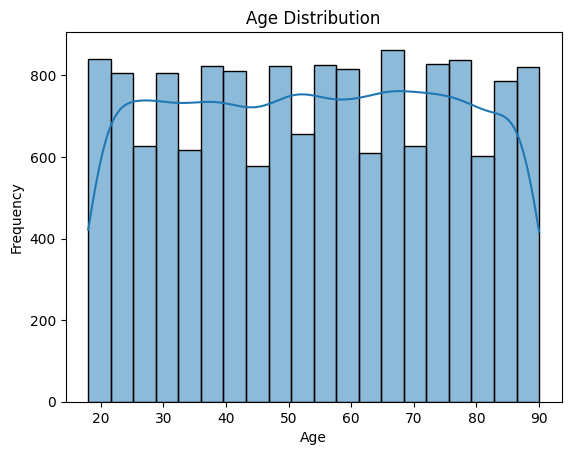

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Insights :**

* *The histogram illustrates the distribution of patient age. The values range from approximately 18 to 90 years, with a relatively even distribution across age groups. This indicates that the dataset includes a broad representation of adult ICU patients, making age a relevant feature for mortality prediction.*

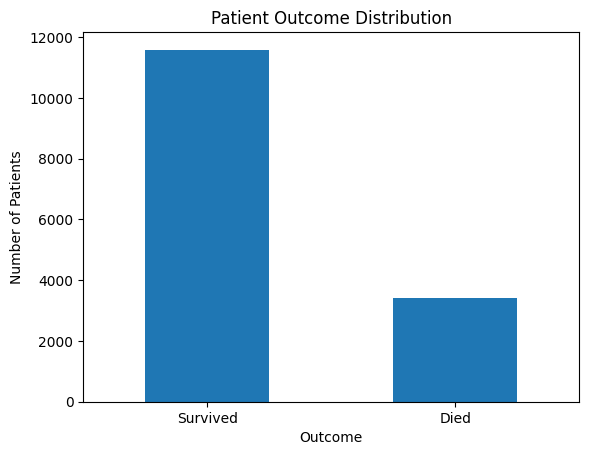

In [ ]:
import matplotlib.pyplot as plt

data['mortality_text'] = data['mortality_label'].map({0: 'Survived', 1: 'Died'})
data['mortality_text'].value_counts().plot(kind='bar')

plt.title("Patient Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

**Insights :**
* *This graph shows the distribution of patient outcomes in the dataset*
* *The majority of patients survived, while a smaller portion died*
* *This indicates that the dataset is imbalanced, where survival is the dominant class*
* *This imbalance is important because it may affect model performance, requiring evaluation metrics beyond accuracy*


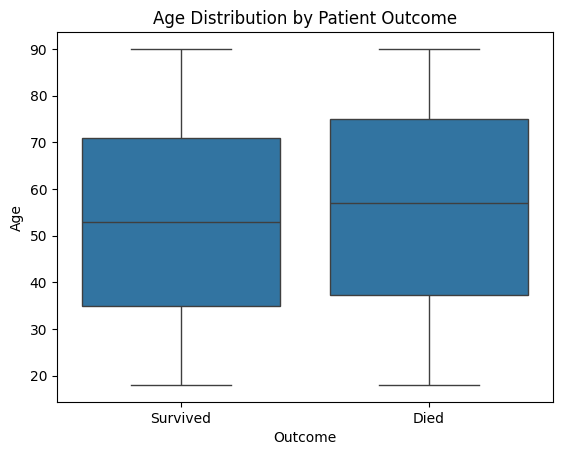

In [ ]:
import seaborn as sns

sns.boxplot(x='mortality_text', y='age', data=data)

plt.title("Age Distribution by Patient Outcome")
plt.xlabel("Outcome")
plt.ylabel("Age")
plt.show()

**Insights :**

* *This graph compares the age distribution between patients who survived and those who died. The median age is higher among patients who died, indicating that older patients tend to have a higher mortality risk.*

* *However, there is a noticeable overlap between the two groups, which suggests that age alone is not sufficient to determine patient outcome. Instead, age should be considered alongside other clinical variables when estimating mortality risk.*

* *This finding aligns with clinical knowledge, as older patients typically have reduced physiological reserve and are more vulnerable to severe illness and complications.*

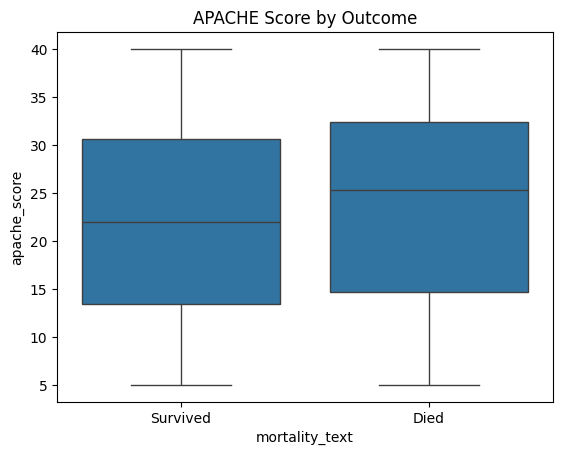

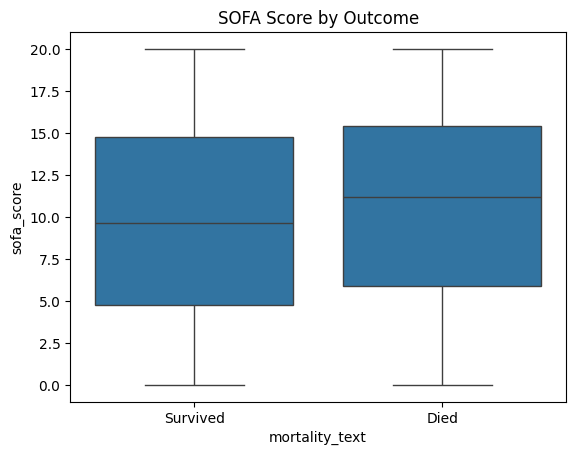

In [ ]:
# APACHE
sns.boxplot(x='mortality_text', y='apache_score', data=data)
plt.title("APACHE Score by Outcome")
plt.show()

# SOFA
sns.boxplot(x='mortality_text', y='sofa_score', data=data)
plt.title("SOFA Score by Outcome")
plt.show()

**Insights :**

* *Both graphs show that patients who died have higher APACHE and SOFA scores.*
* *This confirms that these scores are strong indicators of patient severity.*
* *Higher scores reflect greater organ dysfunction and physiological instability.*
* *These variables are expected to be among the most important predictors in the model.*

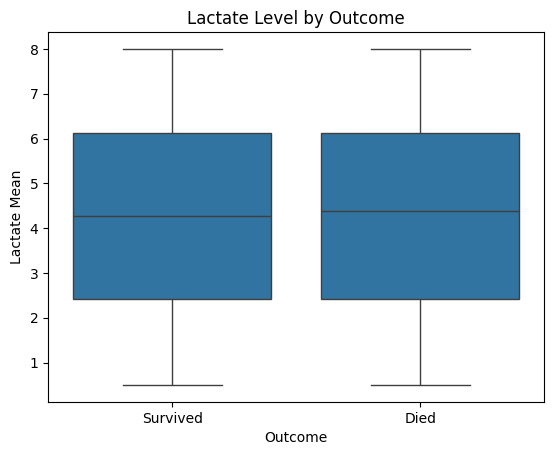

In [ ]:
sns.boxplot(x='mortality_text', y='lactate_mean', data=data)

plt.title("Lactate Level by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Lactate Mean")
plt.show()

**Insight :**

* This graph compares lactate levels between patients who survived and those who died.
* The median lactate level appears slightly higher among patients who died, but the difference is not as strong as the separation seen for APACHE score, SOFA score, ventilation, or vasopressor use.
* Lactate may still be clinically relevant, especially in severe illness and poor perfusion states, but in this dataset it appears to be a weaker visual indicator than some other variables.

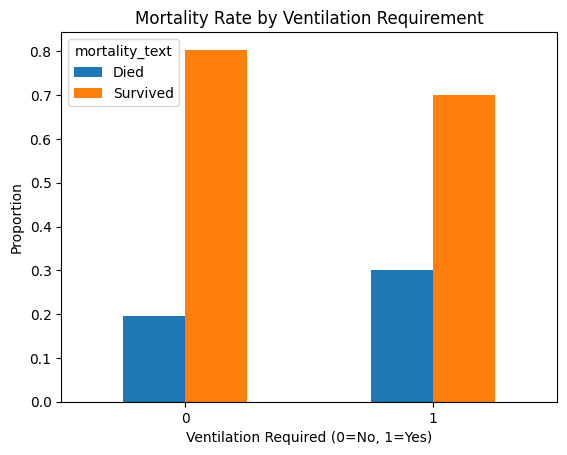

In [ ]:
pd.crosstab(data['ventilation_required'], data['mortality_text'], normalize='index').plot(kind='bar')

plt.title("Mortality Rate by Ventilation Requirement")
plt.xlabel("Ventilation Required (0=No, 1=Yes)")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

**Insight**

* *This graph shows the proportion of outcomes for patients with and without ventilation.*
* *Patients requiring ventilation have a higher proportion of death compared to those who do not.*
* *This indicates that ventilation is strongly associated with severe patient condition.*
* *It suggests that patients needing respiratory support are at higher mortality risk.*

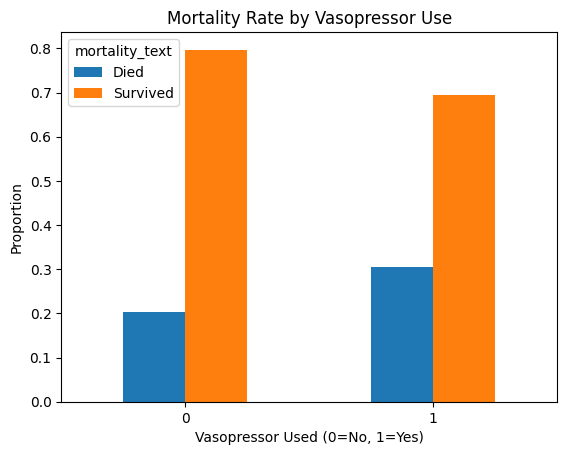

In [ ]:
pd.crosstab(data['vasopressor_used'], data['mortality_text'], normalize='index').plot(kind='bar')

plt.title("Mortality Rate by Vasopressor Use")
plt.xlabel("Vasopressor Used (0=No, 1=Yes)")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

**Insight**

* *Patients who received vasopressors show a higher death proportion than those who did not.*
* *This is expected because vasopressors are used in cases of severe circulatory failure.*
* *This confirms that circulatory instability is strongly linked to mortality risk.*

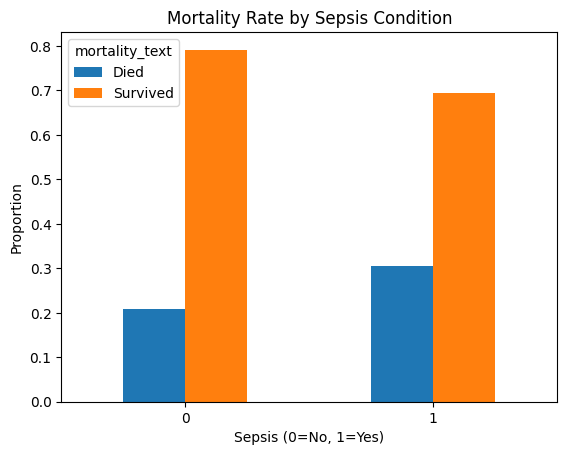

In [ ]:
pd.crosstab(data['sepsis_flag'], data['mortality_text'], normalize='index').plot(kind='bar')

plt.title("Mortality Rate by Sepsis Condition")
plt.xlabel("Sepsis (0=No, 1=Yes)")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

**Insight**

* *Patients with sepsis have a higher mortality proportion compared to non-septic patients.*
* *This confirms that sepsis is a major risk factor in ICU outcomes.*
* *It reinforces findings from literature that sepsis is strongly associated with deterioration and death.*

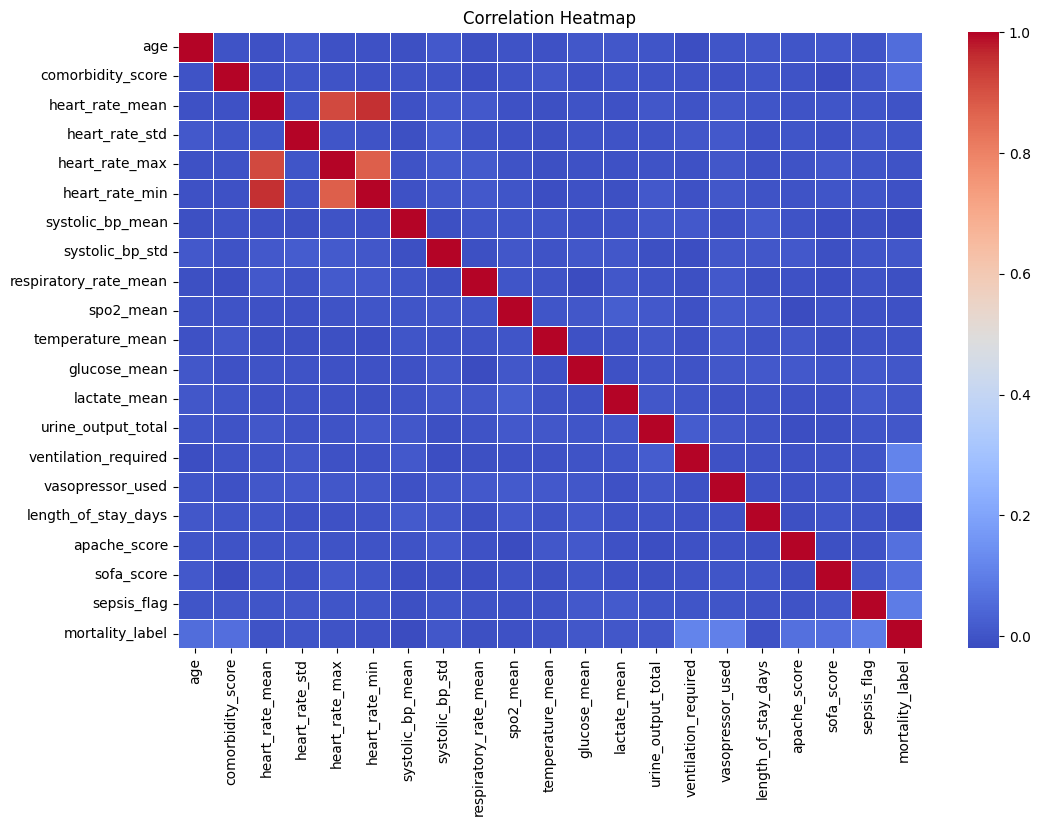

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), cmap='coolwarm', annot=False, linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

**Insights :**

* *This heatmap shows the correlation between numerical features in the dataset.*
* *Strong positive correlations indicate that two variables increase together, while negative correlations indicate inverse relationships.*
* *Some variables, such as APACHE and SOFA scores, may show stronger correlations with mortality-related features.*
* *Highly correlated features may indicate redundancy and should be considered during feature selection to avoid multicollinearity.*

### **Key Insights from EDA**

- Mortality is imbalanced (~23% deaths)
- Older patients tend to have higher mortality risk
- Higher APACHE and SOFA scores indicate higher risk
- Lactate is elevated in high-risk patients
- Ventilation and vasopressor use are associated with severe cases
- Sepsis significantly increases patient risk

These findings align with clinical knowledge and literature, confirming that severity and physiological instability are key drivers of ICU mortality.

## **3.2 : Act / Interpret**

## **Interpretation**

> From the analysis, mortality appears to be strongly influenced by multiple clinical factors. Age shows a clear relationship with mortality risk, where older patients tend to have higher mortality rates. Severity scores such as APACHE and SOFA are strongly associated with outcomes, as they summarize overall organ dysfunction and patient condition.
>
> Physiological indicators, including elevated lactate levels and abnormal heart rate, reflect instability and poor tissue perfusion, which are critical signs in ICU patients. In addition, treatment-related variables such as mechanical ventilation and vasopressor use are highly associated with mortality, as they typically indicate severe illness requiring intensive support. The presence of sepsis further increases mortality risk due to its systemic impact on organ function.
>
> Overall, variables such as APACHE score, SOFA score, lactate levels, ventilation status, and vasopressor use demonstrate strong associations with mortality. These findings confirm that the dataset contains meaningful clinical signals and that these features are likely to play a significant role in predictive modeling of patient outcomes.


# 🟠 **Step 4: Prepare Data for Modeling (Initial 22-Feature Set)**

In this practical section, the goal is not only to classify patients as **survived** or **died**, but to estimate the **probability of mortality** and interpret that probability as a **mortality risk score**.

The modeling stage follows these principles:

- **Target variable:** `mortality_label`
- **Goal:** estimate mortality risk probability
- **Prevent leakage:** remove identifiers and any columns that directly reveal the outcome
- **Use proper preprocessing:** imputation, encoding, and scaling inside pipelines
- **Compare multiple models:** Logistic Regression, Decision Tree, Random Forest, SVM, and Gradient Boosting
- **Evaluate fairly:** accuracy, precision, recall, F1-score, and ROC-AUC
- **Interpret predictions:** convert predicted probabilities into Low / Medium / High risk groups

##  **4.1: Define Target and Features**

In [ ]:
# ==============================
# Step 4.1 - Define target and features
# ==============================

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Work on a clean copy
model_data = data.copy()

# Remove helper columns created during EDA if they exist
helper_cols = ['mortality_text']
model_data = model_data.drop(columns=helper_cols, errors='ignore')

# Define target
target_col = 'mortality_label'
if target_col not in model_data.columns:
    raise ValueError("Target column 'mortality_label' was not found in the dataset.")

# Columns that should not be used as predictors
possible_leakage_or_id_cols = [
    'patient_id', 'PatientID', 'id', 'ID',
    'subject_id', 'stay_id', 'hadm_id',
    'death', 'died', 'outcome', 'mortality_text'
]

drop_cols = [col for col in possible_leakage_or_id_cols if col in model_data.columns and col != target_col]

X = model_data.drop(columns=[target_col] + drop_cols, errors='ignore')
y = model_data[target_col].astype(int)

print("Target distribution:")
print(y.value_counts())
print("\nFeature matrix shape:", X.shape)
print("Dropped columns:", drop_cols)

Target distribution:
mortality_label
0    11582
1     3418
Name: count, dtype: int64

Feature matrix shape: (15000, 22)
Dropped columns: []


### Why this step matters

This step clearly separates:

- **X** = the patient features used for learning
- **y** = the mortality outcome to predict

It also removes identifiers such as `patient_id`, because they do not represent clinical information and may harm the model.

## **4.2: Split Data into Train and Test Sets**

In [ ]:
# ==============================
# Step 4.2 - Split data into train and test sets
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set shape: (12000, 22)
Test set shape: (3000, 22)

Training target distribution:
mortality_label
0    0.772
1    0.228
Name: proportion, dtype: float64

Test target distribution:
mortality_label
0    0.772
1    0.228
Name: proportion, dtype: float64


A **stratified split** is used so that the proportion of deaths and survivals remains similar in both the training and test sets.  
This is important because the dataset is imbalanced.

# 🟡 **Step 5: Build a Proper Preprocessing Pipeline**

Different columns may have different data types:

- **numeric features** such as age, lactate, SOFA, APACHE
- **categorical / binary features** such as ventilation or vasopressor use

To avoid mistakes and data leakage, preprocessing is done **inside a pipeline**.

In [ ]:
# ==============================
# Step 5 - Preprocessing
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Detect numeric and categorical columns automatically
numeric_features = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = [col for col in X_train.columns if col not in numeric_features]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Numeric pipeline: impute missing values then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute missing values then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Full preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Numeric features: 20
Categorical features: 2


This preprocessing design ensures that:

- missing values are handled correctly
- categorical data is converted into numeric form
- scaling is applied only where needed
- all preprocessing is fit on the training data only

# 🟢 **Step 6: Train Multiple Machine Learning Models**

To make the project stronger and more aligned with the plan, several models are trained and compared:

1. Logistic Regression – simple and interpretable baseline  
2. Decision Tree – easy to visualize and explain  
3. Random Forest – more powerful ensemble model  
4. Support Vector Machine (SVM) – strong classifier for complex boundaries  
5. Gradient Boosting – sequential boosting model for improved performance  
6. XGBoost – advanced boosting-based model for structured tabular data  
7. Tuned XGBoost – the same XGBoost model evaluated using an optimized threshold to improve mortality detection

Training several models is useful because ICU mortality may depend on both:

- **linear effects** (for example, increasing age or SOFA score)
- **nonlinear interactions** (for example, combinations of sepsis, ventilation, and lab values)

The tuned XGBoost version is included because, in healthcare prediction, adjusting the classification threshold can improve recall for high-risk patients even when the underlying trained model remains the same.

In [ ]:
!pip install xgboost

# ==============================
# Step 6 - Train multiple models
# ==============================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=3.4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )
}

model_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    model_pipelines[name] = pipeline

# Add Tuned XGBoost as an additional evaluated model
model_pipelines['Tuned XGBoost'] = model_pipelines['XGBoost']

print("All models trained successfully.")

KeyboardInterrupt: 

Training several models is useful because ICU mortality may depend on both:

- **linear effects** (for example, increasing age or SOFA score)
- **nonlinear interactions** (for example, combinations of sepsis, ventilation, and lab values)

# 🔵 **Step 7: Evaluate the Models for Experiment 1**

Several metrics were used to evaluate model performance because accuracy alone is not sufficient for ICU mortality prediction.

### **Accuracy**
Accuracy measures the percentage of all correct predictions. However, because most patients survived in this dataset, a model could achieve relatively high accuracy by predicting many patients as survivors while failing to detect death cases.

### **Recall**
Recall measures how many actual death cases were correctly identified.

This is one of the most important metrics in this project because missing high-risk patients may reduce the opportunity for early intervention.

### **Precision**
Precision measures how many patients predicted as death actually belonged to the death class.

Higher precision means fewer false alarms.

### **F1-Score**
F1-score balances recall and precision. It is useful when both missed death cases and false alarms matter.

### **ROC-AUC**
ROC-AUC evaluates how well the model separates survivors from non-survivors across multiple probability thresholds.

It is a strong comparison metric, but it should not be used alone in imbalanced healthcare problems.

### **Final Selection Logic**
Because ICU mortality prediction focuses on identifying high-risk patients, greater importance was given to **Recall** and **F1-score** rather than accuracy alone.

## **7.1: Evaluate All Models**

In [ ]:
# ==============================
# Step 7.1 - Evaluate all models
# ==============================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

results = []
predictions_store = {}

for name, pipeline in model_pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Apply custom threshold only for Tuned XGBoost
    if name == 'Tuned XGBoost':
        y_pred = (y_prob >= 0.413).astype(int)
    else:
        y_pred = pipeline.predict(X_test)

    predictions_store[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df['Rank_Score'] = (
    0.45 * results_df['Recall'] +
    0.35 * results_df['F1-Score'] +
    0.20 * results_df['ROC-AUC']
)

results_df = results_df.sort_values(
    by=['Rank_Score', 'Recall', 'F1-Score', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

results_df

In [ ]:
# display rounded results
results_df.style.format({
    'Accuracy': '{:.3f}',
    'Precision': '{:.3f}',
    'Recall': '{:.3f}',
    'F1-Score': '{:.3f}',
    'ROC-AUC': '{:.3f}'
})

### Final Selection Logic

Several models were compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Because ICU mortality prediction focuses on identifying high-risk patients, Recall and F1-score were treated as especially important metrics, since missing death cases may be more harmful than producing additional false alarms.

Although some models achieved higher overall accuracy, the Tuned XGBoost model produced the strongest balance of mortality detection performance under the selected ranking criteria.

After threshold tuning, Tuned XGBoost achieved the highest Rank Score and was therefore selected as the final model for detailed evaluation.

## **7.2: Identify the Best Model**

In [ ]:
# ==============================
# Step 7.2 - Identify the best model
# ==============================

best_model_name = results_df.loc[0, 'Model']
best_pipeline = model_pipelines[best_model_name]
best_y_pred = predictions_store[best_model_name]['y_pred']
best_y_prob = predictions_store[best_model_name]['y_prob']

print("Best model based on the selected ranking criteria:", best_model_name)

### Why Tuned XGBoost Was Selected

XGBoost is a strong boosting-based algorithm that often performs well on structured tabular healthcare datasets.

Its default threshold produced moderate recall, but after threshold tuning the model identified a substantially larger proportion of death cases.

Because this project prioritizes mortality detection rather than accuracy alone, the tuned XGBoost version became the strongest final candidate.

# 🟣 **Step 8: Detailed Evaluation of the Final Model in Experiment 1**

## **8.1 Classification Report for the Best Model**

In [ ]:
# ==============================
# Step 8.1 - Detailed Evaluation of Final Model
# ==============================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Use tuned threshold predictions
best_model_name = "Tuned XGBoost"

best_y_prob = model_pipelines['XGBoost'].predict_proba(X_test)[:,1]
best_y_pred = (best_y_prob >= 0.413).astype(int)

print("Best Model:", best_model_name)

print("\nClassification Report:\n")
print(classification_report(y_test, best_y_pred, digits=3))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, best_y_pred))

print("\nAccuracy:", round(accuracy_score(y_test, best_y_pred),3))

## **8.2: Confusion Matrix**

In [ ]:
# ==============================
# Step 8.2 - Confusion Matrix
# ==============================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, best_y_pred)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

### **Confusion Matrix Interpretation (Experiment 1)**

The confusion matrix provides a detailed summary of how the Tuned XGBoost model classified ICU mortality outcomes in Experiment 1:

- **1081** survivors were correctly predicted as survivors (**True Negatives**)
- **489** death cases were correctly predicted as death/high-risk (**True Positives**)
- **1235** survivors were incorrectly predicted as death/high-risk (**False Positives**)
- **195** death cases were incorrectly predicted as survivors (**False Negatives**)

**Key Insights**

The model successfully identified a large proportion of actual death cases, which is reflected in the strong recall score. This is important in ICU mortality prediction because detecting high-risk patients early may support faster intervention.

However, the number of false positive predictions was also high. This means many survivors were flagged as high risk even though they did not belong to the mortality class.

This behavior suggests that the tuned model became more aggressive in detecting mortality risk. While this reduces missed death cases, it also lowers precision and overall accuracy.

**What We Learned**

This result shows why accuracy alone should not be the only evaluation metric in healthcare prediction tasks. In some cases, generating more alerts may be acceptable if it helps capture more truly critical patients.

##  **8.3: ROC Curves for All Models**

In [ ]:
# ==============================
# Step 8.3 - ROC Curves for all models
# ==============================

from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))
for name, pipeline in model_pipelines.items():
    RocCurveDisplay.from_predictions(
        y_test,
        predictions_store[name]['y_prob'],
        name=name,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curves - Model Comparison")
plt.show()

### **ROC Curve Interpretation (Experiment 1)**

The ROC curves compare how effectively each model distinguishes between survivors and non-survivors across all possible classification thresholds.

Each curve plots:

- **True Positive Rate (Recall)** on the y-axis  
- **False Positive Rate** on the x-axis

A model with a curve closer to the **top-left corner** has stronger classification ability, since it achieves higher recall while keeping false positives lower.

**Key Insights from the Graph**

The curves of all tested models are relatively close to each other, which indicates that overall discrimination performance was similar across models.

The reported ROC-AUC values range around **0.62 to 0.63**, meaning the models performed better than random guessing, but only with moderate predictive strength.

Although Logistic Regression, Random Forest, and Gradient Boosting achieved slightly higher ROC-AUC values, this metric alone was not sufficient for final model selection.

**What We Learned**

In ICU mortality prediction, the most important goal is not only separating classes statistically, but also identifying as many true death cases as possible.

For this reason, ROC-AUC was interpreted together with **Recall** and **F1-score**. A model with slightly lower ROC-AUC may still be more useful if it detects more high-risk patients.

Overall, the ROC analysis shows that no model dominated strongly in discrimination performance, so practical metrics were necessary to choose the final model.

## **8.4: Precision-Recall Curve**

Because ICU mortality prediction is an imbalanced classification problem, the Precision-Recall curve is especially useful.

It focuses directly on the trade-off between:

- **Precision** → how many predicted deaths were correct  
- **Recall** → how many actual deaths were identified

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8,6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    best_y_prob,
    name=best_model_name
)

plt.title("Precision-Recall Curve")
plt.show()

### **Precision-Recall Curve Interpretation (Experiment 1)**

The Precision-Recall Curve evaluates how model performance changes across different probability thresholds, with a specific focus on the positive class (death cases).

This graph is especially useful in ICU mortality prediction because the dataset is imbalanced, meaning death cases are less frequent than survival cases. In such situations, Precision-Recall analysis is often more informative than accuracy alone.

- **Recall** shows how many actual death cases were successfully identified.
- **Precision** shows how many patients predicted as death were truly death cases.

The curve illustrates the trade-off between detecting more high-risk patients and increasing false positive alerts.

In this project, the model achieved stronger recall at lower thresholds, meaning more death cases could be captured, but with lower precision. This is expected in healthcare risk prediction, where missing a critical patient may be more serious than generating additional warnings.

Overall, the Precision-Recall Curve supports the final evaluation by showing that the selected model can prioritize mortality detection while maintaining a reasonable balance between sensitivity and false alarms.

# ⚪ **Step 9: Final Threshold Selection for Risk-Sensitive Prediction**

Threshold tuning was incorporated during model optimization to determine whether the default XGBoost cutoff (**0.50**) could be improved for ICU mortality detection.

Multiple probability thresholds were assessed using the Precision-Recall relationship, and the threshold that produced the strongest F1-score was **0.413**.

This lower threshold increased Recall, allowing the model to identify a larger proportion of true mortality cases.

Although this introduced more false positive predictions and reduced overall accuracy, the trade-off was considered acceptable because missing a truly high-risk ICU patient may be more serious than generating additional alerts.

Therefore, **0.413** was selected as the final operating threshold for the Tuned XGBoost model in Experiment 1.

# 🟤 **Step 10: Convert Predicted Probability into Mortality Risk Levels**

To make the result easier to interpret, predicted probabilities are converted into three severity groups:

- **Low Risk**
- **Medium Risk**
- **High Risk**

Instead of using arbitrary cutoffs that may produce empty groups, the notebook uses **quantile-based thresholds** so all three levels are represented in practice.

In [ ]:
# ==============================
# Step 10 - Risk stratification
# ==============================

risk_df = pd.DataFrame({
    'Actual Outcome': y_test.values,
    'Predicted Probability': best_y_prob
})

# Quantile-based thresholds ensure Low / Medium / High categories all appear
low_cut, high_cut = risk_df['Predicted Probability'].quantile([0.33, 0.66])

def risk_category(prob):
    if prob <= low_cut:
        return 'Low'
    elif prob <= high_cut:
        return 'Medium'
    else:
        return 'High'

risk_df['Risk Level'] = risk_df['Predicted Probability'].apply(risk_category)

print("Risk thresholds:")
print("Low cutoff  :", round(low_cut, 3))
print("High cutoff :", round(high_cut, 3))

risk_df.head()

In [ ]:
# Order categories properly
risk_counts = risk_df['Risk Level'].value_counts().reindex(['Low', 'Medium', 'High'])

plt.figure(figsize=(8,5))
bars = plt.bar(risk_counts.index, risk_counts.values)

# Add count labels above bars
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 10,
        int(h),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(f"Predicted Risk Level Distribution - {best_model_name}")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.show()

### Predicted Risk Level Interpretation

Predicted mortality probabilities were grouped into three relative risk categories using quantile-based thresholds.

This means:

- Low Risk = lower third of predicted probabilities
- Medium Risk = middle third
- High Risk = upper third

This method was used to create balanced comparison groups and test whether higher predicted risk levels were associated with higher real mortality.

These groups are relative model-based categories, not fixed clinical cutoffs.

In [ ]:
# Mortality rate inside each predicted risk category
risk_summary = risk_df.groupby('Risk Level')['Actual Outcome'].agg(['count', 'mean']).rename(
    columns={'count': 'Patients', 'mean': 'Observed Mortality Rate'}
).sort_values(by='Observed Mortality Rate')

risk_summary

These risk groups are intended for interpretation only. Because quantile-based thresholds were used, they should not be treated as formal clinical cutoffs.

# ⚫ **Step 11: Feature Importance / Clinical Interpretation**

Feature importance was extracted from the final Tuned XGBoost model to identify which variables contributed most strongly to mortality prediction.

This step is important because, in healthcare projects, prediction accuracy alone is not enough. It is also necessary to understand which clinical features influenced the model’s decisions.

In [ ]:
# ==============================
# Step 11 - Get transformed feature names
# ==============================

# Get feature names after preprocessing
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Access trained estimator
best_estimator = best_pipeline.named_steps['model']

print("Best estimator type:", type(best_estimator).__name__)
print("Number of transformed features:", len(feature_names))

In [ ]:
# Tree-based importance or logistic coefficients depending on best model
if hasattr(best_estimator, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_estimator.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    importance_metric_name = 'Importance'

elif hasattr(best_estimator, 'coef_'):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': np.abs(best_estimator.coef_[0])
    }).sort_values(by='Importance', ascending=False)

    importance_metric_name = 'Absolute Coefficient'
else:
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': np.nan
    })
    importance_metric_name = 'Importance'

importance_df.head(10)

In [ ]:
top_importance = importance_df.head(10)

plt.figure(figsize=(9, 6))
sns.barplot(data=top_importance, x='Importance', y='Feature')
plt.title(f"Top 10 Most Important Features - {best_model_name}")
plt.xlabel(importance_metric_name)
plt.ylabel("Feature")
plt.show()

### **Feature Importance and Practical Interpretation**

The most influential predictors in the final model were:

- ventilation requirement  
- vasopressor use  
- sepsis flag  
- comorbidity score  
- SOFA score  
- age  
- APACHE score  

These variables are clinically meaningful because they reflect illness severity, organ dysfunction, treatment intensity, and underlying patient vulnerability.

Patients requiring ventilation or vasopressors are often among the most critically ill ICU cases, while sepsis is strongly associated with deterioration and mortality risk. Likewise, SOFA and APACHE are widely recognized severity indicators, so their importance supports the realism of the model.

The model achieved moderate predictive performance rather than unrealistically high scores, which is expected in ICU mortality prediction. Survivors and non-survivors often share overlapping clinical patterns, making perfect separation difficult in real healthcare data.

Because the dataset is imbalanced, overall Accuracy was not treated as the main success metric. Greater emphasis was placed on **Recall**, since failing to identify a truly high-risk patient may be more serious than generating additional false alarms.

For this reason, the selected model accepted more false positive predictions in exchange for detecting a larger proportion of mortality cases.

Overall, the results should be interpreted as a realistic and clinically oriented balance between mortality detection and overall predictive performance, rather than an attempt to maximize accuracy alone.

# ❗**Step 12: Final Practical Conclusion for Experiment 1 (Initial 22-Feature Set)**

The practical part of the project successfully followed the proposed workflow:

- the ICU dataset was loaded and understood  
- the data was cleaned and prepared  
- exploratory data analysis was used to examine factors associated with mortality  
- multiple machine learning models were trained and compared  
- model performance was evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC  
- threshold tuning was applied to improve mortality detection  
- predicted probabilities were interpreted as mortality risk  
- risk probabilities were grouped into Low, Medium, and High categories for easier interpretation  
- feature importance was analyzed to identify the strongest clinical predictors  

After comparing all tested models, the Tuned XGBoost model was selected as the final model based on the selected evaluation criteria. Although it did not achieve the highest overall accuracy, it produced the strongest balance of Recall and F1-score after threshold tuning, making it more suitable for identifying high-risk ICU patients in an imbalanced dataset.

The analysis also showed that higher risk was strongly associated with features such as **ventilation requirement, vasopressor use, sepsis, comorbidity score, APACHE score, SOFA score, and age**. These findings are consistent with the earlier exploratory analysis and suggest that the model captured clinically meaningful patterns.

Overall, the notebook demonstrates that ICU mortality prediction should not be evaluated using accuracy alone. A more useful approach is to balance predictive discrimination with the ability to detect death cases, while also interpreting the clinical factors that contribute most strongly to model decisions.


# ➕ **Step 13: Save Key Outputs**

In [ ]:
# ==============================
# Step 13 - Save key outputs (extra)
# ==============================

print("Best model:", best_model_name)
print("\nModel comparison:")
display(results_df)

print("\nRisk summary:")
display(risk_summary)

print("\nTop important features:")
display(importance_df.head(10))

### **Note on Noisy or Weaker Features**

The original dataset contained a broader mixed feature set with varying predictive usefulness.

In this project, feature reduction was used as a practical way to handle weaker or noisier predictors by removing less useful variables and retaining the most clinically meaningful mortality indicators.

This helped improve interpretability and reduced unnecessary model complexity before the final optimized experiment.

---
# ⚠ **Transition to Experiment 2: Refined 7-Feature Modeling on the Original Imbalanced Data**

Experiment 1 established a baseline using the initial 22-feature set and showed that clinically meaningful mortality prediction was possible. However, the results also suggested two important limitations:

- the larger feature set may include redundant or weaker predictors,
- and the original dataset imbalance may influence model behavior, especially recall, precision, and false positive rates.

To improve interpretability and reduce unnecessary complexity, a second experiment was conducted using a refined set of 7 features selected through correlation analysis, p-values, and clinical relevance.

Before introducing any balancing technique, this experiment first keeps the **original imbalanced class distribution**. This makes it possible to study the effect of feature refinement by itself, without changing the class composition at the same time.

# **Experiment 2: Refined 7-Feature Modeling on the Original Imbalanced Data**

# 🟥⭐ **Step 3: Refined Feature Selection and EDA for the 7-Feature Dataset**
After completing the baseline experiment, additional statistical validation was performed to refine the dataset further.  
Although the earlier heatmap suggested that many variables might be related to mortality, a more careful analysis using correlation values and p-values was needed to identify the most reliable predictors.

This step focuses on:

- reviewing the original correlation heatmap,
- measuring correlation with the mortality label,
- checking statistical significance using p-values,
- selecting the final 7 most meaningful features,
- creating a reduced dataset for the next modeling stage,
- and visualizing the relationship between the selected features and mortality.

At this stage, the dataset still keeps the **original imbalanced class distribution**.  
This allows the effect of **feature refinement alone** to be studied first, before applying any balancing method in the following experiment.

## **3.1: Review of the Initial Correlation Heatmap**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), cmap='coolwarm', annot=False, linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

### Insights:
- The initial heatmap suggested that multiple features may be associated with mortality.
- However, visual inspection alone is not enough to confirm feature importance.
- For this reason, correlation values and p-values were examined next.

## **3.2: Signed Correlation with Mortality Label**

In [ ]:
corr_matrix = numeric_data.corr()

corr_with_target = corr_matrix['mortality_label'].sort_values(ascending=False)
display(corr_with_target)

### Insights:
- Positive values indicate that higher feature values are associated with higher mortality risk.
- Negative values indicate an inverse relationship with mortality.
- Features with stronger correlation values deserve closer evaluation.

## **3.3: Absolute Correlation Ranking**

In [ ]:
corr_abs_ranked = corr_matrix['mortality_label'].drop('mortality_label').abs().sort_values(ascending=False)
display(corr_abs_ranked)

### Insights:
- Absolute correlation helps rank feature strength regardless of direction.
- This makes it easier to identify the variables most strongly related to mortality.
- However, correlation alone is still not enough, so statistical significance was checked next.

## **3.4: Correlation and P-Value Analysis**

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

results = []

for col in numeric_data.columns:
    if col != 'mortality_label':
        r, p = pearsonr(numeric_data[col], numeric_data['mortality_label'])
        results.append({
            'Feature': col,
            'Correlation_r': r,
            'P_Value': p,
            'Abs_r': abs(r)
        })

corr_p_df = pd.DataFrame(results).sort_values(by='Abs_r', ascending=False).reset_index(drop=True)

display(
    corr_p_df[['Feature', 'Correlation_r', 'P_Value']].style.format({
        'Correlation_r': '{:.4f}',
        'P_Value': '{:.6f}'
    })
)

### Insights:
- P-values were used to confirm whether the observed relationships were statistically meaningful.
- Features with lower p-values provide stronger evidence of a real relationship with mortality.
- This step improves the reliability of the final feature selection process.

## **3.5: Significant Features Based on Statistical Testing**

In [ ]:
significant_correlations = corr_p_df[corr_p_df['P_Value'] < 0.1].sort_values(by='Abs_r', ascending=False)

display(
    significant_correlations[['Feature', 'Correlation_r', 'P_Value']].style.format({
        'Correlation_r': '{:.4f}',
        'P_Value': '{:.6f}'
    })
)

### Insights:
- Only statistically significant features were considered for refinement.
- This reduced the chance of keeping weak or misleading predictors.
- The next step was to choose the final features that were both statistically supported and clinically meaningful.

## **3.6 Final Selected Features**

The final 7 selected features used in this refined experiment are:

1. `ventilation_required`  
2. `vasopressor_used`  
3. `sepsis_flag`  
4. `apache_score`  
5. `sofa_score`  
6. `comorbidity_score`  
7. `age`  

These variables were selected based on correlation strength, p-value significance, and clinical relevance to ICU mortality prediction.

## **3.7: Create the Reduced Dataset with the Final 7 Features**

In [ ]:
selected_feature_names = [
    'ventilation_required',
    'vasopressor_used',
    'sepsis_flag',
    'apache_score',
    'sofa_score',
    'comorbidity_score',
    'age'
]

selected_dataset = data[selected_feature_names + ['mortality_label']].copy()

print("Shape of the reduced dataset:", selected_dataset.shape)
display(selected_dataset.head())

### Insights:
- A reduced dataset was created using only the final 7 selected features and the target variable.
- This refined dataset will be used in the next modeling steps of Experiment 2.
- Reducing the dataset helps simplify the model while preserving clinically meaningful predictive information.

## **3.8: Relationship Between Final Selected Features and Mortality**
The following visualizations were created to examine how each selected feature relates to mortality.  
These plots help confirm that the refined 7-feature set still captures meaningful clinical differences between survivors and non-survivors.

## **3.8.1: Ventilation Requirement vs Mortality Outcome**

In [ ]:
plot_data = selected_dataset.copy()
plot_data['ventilation_label'] = plot_data['ventilation_required'].map({0: 'No', 1: 'Yes'})
plot_data['mortality_text'] = plot_data['mortality_label'].map({0: 'Survived', 1: 'Died'})

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='ventilation_label', hue='mortality_text', data=plot_data, palette='coolwarm')

plt.title('Mortality Outcome by Ventilation Requirement')
plt.xlabel('Ventilation Required')
plt.ylabel('Number of Patients')
plt.legend(title='Outcome')

total_counts = plot_data.groupby('ventilation_label')['mortality_text'].count()

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + height

    if x < 0.5:
        category_total = total_counts.get('No', 1)
    else:
        category_total = total_counts.get('Yes', 1)

    percentage = 100 * height / category_total
    ax.annotate(f'{percentage:.1f}%', (x, y), ha='center', va='bottom', fontsize=10)

plt.show()

### Insights:
- Patients who required ventilation had a noticeably higher mortality rate.
- This suggests that ventilation requirement is a strong indicator of severe illness.
- The plot supports keeping this feature in the final dataset.

## **3.8.2: Vasopressor Use vs Mortality Outcome**

In [ ]:
plot_data = selected_dataset.copy()
plot_data['vasopressor_label'] = plot_data['vasopressor_used'].map({0: 'No', 1: 'Yes'})
plot_data['mortality_text'] = plot_data['mortality_label'].map({0: 'Survived', 1: 'Died'})

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='vasopressor_label', hue='mortality_text', data=plot_data, palette='coolwarm')

plt.title('Mortality Outcome by Vasopressor Use')
plt.xlabel('Vasopressor Used')
plt.ylabel('Number of Patients')
plt.legend(title='Outcome')

total_counts = plot_data.groupby('vasopressor_label')['mortality_text'].count()

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + height

    if x < 0.5:
        category_total = total_counts.get('No', 1)
    else:
        category_total = total_counts.get('Yes', 1)

    percentage = 100 * height / category_total
    ax.annotate(f'{percentage:.1f}%', (x, y), ha='center', va='bottom', fontsize=10)

plt.show()

### Insights:
- Mortality was higher among patients who received vasopressors.
- This indicates that circulatory instability is strongly associated with poor outcomes.
- The feature appears clinically relevant and statistically useful.

## **3.8.3: Sepsis Status vs Mortality Outcome**

In [ ]:
plot_data = selected_dataset.copy()
plot_data['sepsis_label'] = plot_data['sepsis_flag'].map({0: 'No', 1: 'Yes'})
plot_data['mortality_text'] = plot_data['mortality_label'].map({0: 'Survived', 1: 'Died'})

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='sepsis_label', hue='mortality_text', data=plot_data, palette='coolwarm')

plt.title('Mortality Outcome by Sepsis Status')
plt.xlabel('Sepsis Present')
plt.ylabel('Number of Patients')
plt.legend(title='Outcome')

total_counts = plot_data.groupby('sepsis_label')['mortality_text'].count()

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + height

    if x < 0.5:
        category_total = total_counts.get('No', 1)
    else:
        category_total = total_counts.get('Yes', 1)

    percentage = 100 * height / category_total
    ax.annotate(f'{percentage:.1f}%', (x, y), ha='center', va='bottom', fontsize=10)

plt.show()

### Insights:
- Patients with sepsis showed a higher proportion of death compared to patients without sepsis.
- This confirms that sepsis is an important risk factor in ICU mortality.
- The plot supports the importance of this feature in the predictive model.

## **3.8.4: APACHE Score vs Mortality Outcome**

In [ ]:
plot_data = selected_dataset.copy()
plot_data['mortality_text'] = plot_data['mortality_label'].map({0: 'Survived', 1: 'Died'})

plt.figure(figsize=(8, 6))
sns.boxplot(x='mortality_text', y='apache_score', data=plot_data, hue='mortality_text', palette='coolwarm', legend=False)

plt.title('APACHE Score Distribution by Mortality Outcome')
plt.xlabel('Mortality Outcome')
plt.ylabel('APACHE Score')
plt.show()

### Insights:
- Patients who died generally had higher APACHE scores than those who survived.
- This shows that greater illness severity is associated with higher mortality risk.
- APACHE score appears to be one of the strongest continuous predictors.

## **3.8.5: SOFA Score vs Mortality Outcome**

In [ ]:
plot_data = selected_dataset.copy()
plot_data['mortality_text'] = plot_data['mortality_label'].map({0: 'Survived', 1: 'Died'})

plt.figure(figsize=(8, 6))
sns.boxplot(x='mortality_text', y='sofa_score', data=plot_data, hue='mortality_text', palette='coolwarm', legend=False)

plt.title('SOFA Score Distribution by Mortality Outcome')
plt.xlabel('Mortality Outcome')
plt.ylabel('SOFA Score')
plt.show()

### Insights:
- Higher SOFA scores were observed among non-survivors.
- This indicates that organ dysfunction is strongly linked to mortality.
- The feature remains highly relevant for final modeling.

## **3.8.6: Comorbidity Score vs Mortality Outcome**

In [ ]:
plot_data = selected_dataset.copy()
plot_data['mortality_text'] = plot_data['mortality_label'].map({0: 'Survived', 1: 'Died'})

plt.figure(figsize=(8, 6))
sns.boxplot(x='mortality_text', y='comorbidity_score', data=plot_data, hue='mortality_text', palette='coolwarm', legend=False)

plt.title('Comorbidity Score Distribution by Mortality Outcome')
plt.xlabel('Mortality Outcome')
plt.ylabel('Comorbidity Score')
plt.show()

### Insights:
- Patients who died tended to have higher comorbidity scores.
- This suggests that a heavier chronic disease burden increases mortality risk.
- The feature adds useful baseline health information to the model.

## **3.8.7: Age vs Mortality Outcome**

In [ ]:
plot_data = selected_dataset.copy()
plot_data['mortality_text'] = plot_data['mortality_label'].map({0: 'Survived', 1: 'Died'})

plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_data, x='age', hue='mortality_text', fill=True, common_norm=False, palette='coolwarm')

plt.title('Age Distribution by Mortality Outcome')
plt.xlabel('Age')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Insights:
- The age distribution of non-survivors is shifted slightly toward older ages.
- This suggests that older patients had a greater mortality risk in the ICU.
- Age remains an important demographic predictor in the refined dataset.

While these individual plots show the broad distribution of each feature, they reveal that no single variable acts as a 'silver bullet' for predicting mortality. This justifies the need for the interaction analysis and multivariate modeling in the following sections.


## **3.9: Correlation Heatmap of the Final 7 Features**

In [ ]:
selected_features_df = selected_dataset[selected_feature_names]

plt.figure(figsize=(10, 8))
sns.heatmap(selected_features_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of the Final 7 Selected Features')
plt.show()

### Insights:
- The selected features show meaningful but not identical relationships with one another.
- Severity-related variables such as APACHE score and SOFA score are moderately correlated, which is clinically expected.
- Overall, the final feature set captures different aspects of patient condition, making it suitable for the next modeling stage.

## **3.10: Additional Population-Level Feature Relationship Analysis**

Several additional visualizations were explored to better understand how the selected clinical features relate to one another beyond direct feature-versus-mortality comparisons.

These exploratory analyses included subgroup comparisons such as:

- age group versus sepsis prevalence  
- age group versus severity score distributions  
- sepsis status versus ventilation requirement  
- sepsis status versus vasopressor use  
- sepsis status versus lactate level  
- relationships among selected clinical variables

Many of these patterns appeared weak, nearly uniform, or medically less distinct than expected.

This was due to the structure of the publicly available benchmark dataset used in this project. The dataset supports machine learning experimentation and predictive modeling, but several variables do not show strong real-world subgroup dependencies or clinically progressive relationships across categories.

For this reason, only the most interpretable and informative visualizations were retained in the notebook, while weaker subgroup plots were excluded to avoid overstating unsupported relationships.

As a result, the analysis remained focused on clearer findings such as:

- class imbalance structure  
- selected feature distributions  
- feature correlation patterns  
- feature importance in prediction  
- model performance and interpretability outcomes

Future work could evaluate the same methodology on richer real-world ICU datasets with stronger clinical interactions, external validation cohorts, and more detailed patient trajectories.

This approach ensures that conclusions are based on patterns genuinely supported by the available data rather than assumptions not reflected in the dataset.

## **3.10.1: Relationship Between APACHE and SOFA Scores**

In [ ]:
plot_data = data.copy()

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=plot_data.sample(min(3000, len(plot_data)), random_state=42),
    x='apache_score',
    y='sofa_score',
    alpha=0.6
)

plt.title('Relationship Between APACHE and SOFA Scores')
plt.xlabel('APACHE Score')
plt.ylabel('SOFA Score')

plt.show()

### Insights:

- This scatter plot was used to examine whether two major severity indicators move together.

- The distribution appears widely dispersed with no strong linear relationship between APACHE and SOFA scores.

- In real clinical settings, some positive association is often expected because both scores reflect patient severity through different scoring frameworks.

- The weaker relationship observed here suggests that these variables behave more independently within the benchmark dataset.

- From a machine learning perspective, this also reduces the risk of multicollinearity, allowing the model to use APACHE and SOFA as more distinct predictive inputs rather than highly redundant variables.

- This finding is useful because it highlights both dataset structure characteristics and potential modeling advantages.

## **3.10.2: Distribution of Lactate Levels in the ICU Population**

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(
    data=data,
    x='lactate_mean',
    bins=25,
    kde=True
)

plt.title('Distribution of Lactate Levels')
plt.xlabel('Lactate Mean')
plt.ylabel('Number of Patients')

plt.show()

### Insights:
- This histogram examines how lactate values are distributed across the ICU population.
- The values appear relatively uniform across the available range rather than naturally concentrated around common physiological levels.
- In real hospital datasets, lactate often shows a right-skewed distribution with more patients at lower values and fewer at very high levels.
- The flatter pattern observed here suggests simplified variable generation within the benchmark dataset.
- Despite this limitation, lactate remains useful as a candidate predictor within the machine learning workflow.

## **3.10.3: Combined Effect of Sepsis and Ventilation on Mortality**

In [ ]:
plot_data = data.copy()

def group_label(row):
    if row['sepsis_flag']==0 and row['ventilation_required']==0:
        return 'No Sepsis + No Vent'
    elif row['sepsis_flag']==0 and row['ventilation_required']==1:
        return 'No Sepsis + Vent'
    elif row['sepsis_flag']==1 and row['ventilation_required']==0:
        return 'Sepsis + No Vent'
    else:
        return 'Sepsis + Vent'

plot_data['risk_group'] = plot_data.apply(group_label, axis=1)

mort_rates = plot_data.groupby('risk_group')['mortality_label'].mean()*100

plt.figure(figsize=(10,6))
ax = mort_rates.reindex([
    'No Sepsis + No Vent',
    'No Sepsis + Vent',
    'Sepsis + No Vent',
    'Sepsis + Vent'
]).plot(kind='bar')

plt.title('Combined Effect of Sepsis and Ventilation on Mortality')
plt.ylabel('Mortality Rate (%)')
plt.xlabel('Clinical Group')
plt.xticks(rotation=20)

for i,v in enumerate(mort_rates.reindex([
    'No Sepsis + No Vent',
    'No Sepsis + Vent',
    'Sepsis + No Vent',
    'Sepsis + Vent'
]).values):
    plt.text(i, v+0.3, f'{v:.1f}%', ha='center')

plt.show()

### Insights:

- This visualization examined whether sepsis and ventilation jointly increased mortality risk compared with either factor alone.

- Patients with neither condition (**No Sepsis + No Vent**) showed the lowest mortality rate at **17.5%**, representing the lowest-risk subgroup in the dataset.

- Patients with only one of the two factors showed similar intermediate mortality:
  - **No Sepsis + Ventilation:** **28.5%**
  - **Sepsis + No Ventilation:** **28.1%**

- Patients with both conditions (**Sepsis + Ventilation**) had the highest mortality rate at **36.1%**.

- This pattern suggests an additive combined effect, where multiple indicators of critical illness were associated with greater mortality risk.

- Unlike several weaker subgroup plots explored earlier, this interaction produced a clinically meaningful gradient and was therefore retained in the final notebook.

**Interpretation:**

- Ventilation likely reflects respiratory failure or severe instability.
- Sepsis reflects systemic infection burden.
- When both occur together, mortality risk rises further, which aligns more closely with real ICU expectations.
- This supports the importance of using multiple variables together rather than interpreting single predictors in isolation.

## 3.10.4: SOFA Score Distribution by Mortality Outcome

In [ ]:
plot_data = data.copy()
plot_data['mortality_text'] = plot_data['mortality_label'].map({0:'Survived',1:'Died'})

plt.figure(figsize=(9,6))

sns.violinplot(
    data=plot_data,
    x='mortality_text',
    y='sofa_score',
    palette='coolwarm'
)

plt.title('SOFA Score Distribution by Mortality Outcome')
plt.xlabel('Outcome')
plt.ylabel('SOFA Score')

plt.show()

### Insights:

- This violin plot compares the full distribution of SOFA scores between survivors and non-survivors.

- Patients who died showed a slight upward shift in the score distribution compared with survivors.

- The median and interquartile range were marginally higher in the death group, suggesting somewhat greater organ dysfunction severity.

- However, substantial overlap remains between both groups.

### Interpretation:

- SOFA score alone provides useful signal, but it does not perfectly separate outcomes in this dataset.

- This is realistic in critical care settings, where no single score fully determines survival.

- The overlap supports the use of machine learning models that combine SOFA with additional predictors such as age, APACHE score, ventilation requirement, vasopressor use, and sepsis status.

- This helps explain why multi-feature models outperformed single-variable reasoning in the final experiments.

## **3.10.5: Mortality Rate Across Age Groups with Confidence Intervals**

In [ ]:
plot_data = data.copy()

plot_data['age_group'] = pd.cut(
    plot_data['age'],
    bins=[17,40,60,80,100],
    labels=['18-40','41-60','61-80','80+']
)

plt.figure(figsize=(9,6))

sns.pointplot(
    data=plot_data,
    x='age_group',
    y='mortality_label',
    errorbar=('ci',95),
    capsize=0.15
)

plt.title('Mortality Rate Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Mortality Rate')

plt.show()

### Insights:

- This chart examined whether mortality changed across broader patient age groups.

- Mortality remained similar in younger and middle-age groups:
  - **18–40:** approximately **20.9%**
  - **41–60:** approximately **20.9%**

- Mortality increased in older groups:
  - **61–80:** approximately **25.1%**
  - **80+:** approximately **26.2%**

- The confidence intervals show some uncertainty around each estimate, but the overall upward trend remains visible.

**Interpretation:**

- Older age is commonly associated with reduced physiological reserve, greater frailty, and more complex illness burden.

- This grouped analysis produced a more realistic age-related trend than several weaker subgroup plots explored earlier.

- The result supports age as a meaningful predictor and helps justify why age remained in the final selected feature set.

## **3.11 Summary of Refined EDA**

Based on correlation analysis, p-value testing, and visual examination, the dataset was refined to 7 final predictors of ICU mortality:

- `ventilation_required`
- `vasopressor_used`
- `sepsis_flag`
- `apache_score`
- `sofa_score`
- `comorbidity_score`
- `age`

These variables showed statistically meaningful relationships with mortality while also maintaining clinical relevance for ICU risk prediction.

Beyond standard feature-versus-mortality analysis, additional exploratory visualizations were conducted to better understand interactions between predictors, severity score behavior, and subgroup trends within the patient population.

Meaningful retained findings included:

- stronger mortality risk when sepsis and ventilation occurred together  
- slight upward SOFA score shift among non-survivors  
- increasing mortality across older age groups  
- useful independence between APACHE and SOFA scores, reducing feature redundancy

Several other exploratory subgroup plots were tested but showed weak or nearly uniform patterns. This reflects structural limitations of the benchmark dataset rather than analysis error.

This observation was itself valuable, as it demonstrated the importance of validating whether visual patterns are truly supported by the data before drawing conclusions.

The refined 7-feature dataset remains **imbalanced at this stage**, since the original class distribution was intentionally preserved in order to isolate the effect of feature refinement before applying balancing methods in the next experiment.

Overall, the refined dataset is now well-prepared for preprocessing, model training, and comparative machine learning evaluation in Experiment 2.

# 🟧 **Step 4: Data Preparation for Experiment 2 (Refined 7-Feature Dataset – Original Imbalanced Data)**

After selecting the final 7 clinically meaningful predictors, the next stage is to prepare the refined dataset for machine learning modeling.

In this experiment, the dataset still keeps the **original class imbalance**, where survivor cases remain more common than death cases.

The purpose of this step is to evaluate how much **feature refinement alone** improves model performance before applying any balancing strategy in Experiment 3.

This step includes:

- separating predictors and target labels,
- splitting data into training and testing sets,
- preserving class proportions using stratified sampling,
- identifying numerical and binary variables,
- and preparing the data for preprocessing pipelines.

## **4.1 Define Features and Target Variable**

In [ ]:
# ==============================
# Experiment 2 - Step 4.1
# Define features and target
# ==============================

X_exp2 = selected_dataset.drop('mortality_label', axis=1)
y_exp2 = selected_dataset['mortality_label']

print("Features shape:", X_exp2.shape)
print("Target shape:", y_exp2.shape)

print("\nTarget distribution:")
print(y_exp2.value_counts())

## **4.2 Split the Dataset into Training and Testing Sets**

In [ ]:
# ==============================
# Experiment 2 - Step 4.2
# Train-test split
# ==============================

from sklearn.model_selection import train_test_split

X_train_exp2, X_test_exp2, y_train_exp2, y_test_exp2 = train_test_split(
    X_exp2,
    y_exp2,
    test_size=0.20,
    random_state=42,
    stratify=y_exp2
)

print("X_train_exp2:", X_train_exp2.shape)
print("X_test_exp2 :", X_test_exp2.shape)
print("y_train_exp2:", y_train_exp2.shape)
print("y_test_exp2 :", y_test_exp2.shape)

print("\nTraining target distribution:")
print(y_train_exp2.value_counts())

print("\nTesting target distribution:")
print(y_test_exp2.value_counts())

A **stratified split** was used so that the original imbalance between survivor and death cases remained similar in both the training and testing sets.

This is important because Experiment 2 is designed to test the effect of **feature refinement alone**, while keeping the original class distribution unchanged.

## **4.3 Separate Numerical and Binary Features**

In [ ]:
# ==============================
# Experiment 2 - Step 4.3
# Identify feature types
# ==============================

numerical_features_exp2 = [
    'apache_score',
    'sofa_score',
    'comorbidity_score',
    'age'
]

binary_features_exp2 = [
    'ventilation_required',
    'vasopressor_used',
    'sepsis_flag'
]

print("Numerical Features:", numerical_features_exp2)
print("Binary Features:", binary_features_exp2)

The refined 7-feature dataset contains two variable types:

### Numerical Features
- `apache_score`
- `sofa_score`
- `comorbidity_score`
- `age`

### Binary Features
- `ventilation_required`
- `vasopressor_used`
- `sepsis_flag`

This distinction is useful because numerical variables require scaling, while binary indicators can remain in their current 0/1 format.

## **4.4 Final Check of Split Data**

In [ ]:
# ==============================
# Experiment 2 - Step 4.4
# Final check
# ==============================

print("X_train_exp2 shape:", X_train_exp2.shape)
print("X_test_exp2 shape :", X_test_exp2.shape)
print("y_train_exp2 shape:", y_train_exp2.shape)
print("y_test_exp2 shape :", y_test_exp2.shape)

At this stage:

- the refined 7 predictors were selected,
- the target labels were separated,
- training and testing sets were created,
- the original imbalance was preserved,
- and the dataset is ready for preprocessing.

# 🟨 **Step 5: Build a Preprocessing Pipeline for Experiment 2**
To prepare the selected features consistently for machine learning models, a preprocessing pipeline was created.

Since the refined dataset contains both continuous and binary variables, each type was handled appropriately inside a single pipeline. This helps keep preprocessing organized and prevents data leakage.

## **5.1 Create the Numerical Pipeline**

In [ ]:
# ==============================
# Experiment 2 - Step 5.1
# Numerical pipeline
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer_exp2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_transformer_exp2

The numerical pipeline processes continuous variables in two steps:

- missing values are replaced using the median,
- then the variables are standardized using `StandardScaler`.

This is especially useful for models that are sensitive to differences in scale.

## **5.2 Create the Binary Pipeline**

In [ ]:
# ==============================
# Experiment 2 - Step 5.2
# Binary pipeline
# ==============================

binary_transformer_exp2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

binary_transformer_exp2

The binary pipeline handles the three indicator variables.

Because these predictors are already encoded as `0` and `1`, no additional encoding is needed. Only basic imputation is applied if required.

## **5.3 Combine the Pipelines Using ColumnTransformer**

In [ ]:
# ==============================
# Experiment 2 - Step 5.3
# Full preprocessor
# ==============================

preprocessor_exp2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_exp2, numerical_features_exp2),
        ('bin', binary_transformer_exp2, binary_features_exp2)
    ]
)

preprocessor_exp2

The full preprocessor applies the correct transformation to each feature group:

- numerical columns are imputed and scaled,
- binary columns are imputed and passed through without unnecessary encoding.

This keeps preprocessing consistent and ensures that all transformations are learned only from the training data.

## **5.4 Apply the Preprocessor to the Training and Testing Sets**

In [ ]:
# ==============================
# Experiment 2 - Step 5.4
# Apply preprocessor
# ==============================

X_train_prepared_exp2 = preprocessor_exp2.fit_transform(X_train_exp2)
X_test_prepared_exp2 = preprocessor_exp2.transform(X_test_exp2)

print("Prepared X_train_exp2 shape:", X_train_prepared_exp2.shape)
print("Prepared X_test_exp2 shape :", X_test_prepared_exp2.shape)

The preprocessing pipeline was fitted on the training set and then applied to both training and testing data.

This ensures that:

- preprocessing statistics are learned only from the training data,
- the testing set remains unseen during training,
- and the workflow stays free from data leakage.

## **5.5 Summary of Preprocessing Setup**
The refined 7-feature dataset is now ready for machine learning modeling in Experiment 2.

At this stage:

- the selected features have been separated by type,
- numerical variables are imputed and scaled,
- binary variables are imputed without extra encoding,
- and both training and testing sets are prepared consistently.

# 🟩 **Step 6: Train Multiple Machine Learning Models for Experiment 2**
To strengthen the analysis and provide a reliable comparison, multiple classification models were trained using the refined 7-feature dataset.

The following models were included:

1. **Logistic Regression** – a simple and interpretable baseline  
2. **Decision Tree** – easy to explain and visualize  
3. **Random Forest** – a stronger ensemble-based model  
4. **Support Vector Machine (SVM)** – effective for more complex decision boundaries  
5. **Gradient Boosting** – a sequential boosting approach  
6. **XGBoost** – an advanced boosting model for structured tabular data  
7. **Tuned XGBoost** – the same XGBoost model evaluated with an adjusted threshold to improve mortality detection

## **6.1 Install and Import Required Libraries**

In [ ]:
# ==============================
# Experiment 2 - Step 6.1
# Import models
# ==============================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

The required machine learning libraries were imported, including XGBoost for advanced boosting-based classification.

## **6.2 Define the Models**
### Models Used in This Experiment

To compare different learning strategies, several machine learning models were trained and evaluated:

- **Logistic Regression** – a simple and interpretable baseline model
- **Decision Tree** – easy to understand and useful for capturing rule-based splits
- **Random Forest** – an ensemble method that improves stability by combining many trees
- **Support Vector Machine (SVM)** – a classifier that can model more complex decision boundaries
- **Gradient Boosting** – a boosting method that improves performance sequentially
- **XGBoost** – an advanced boosting model that often performs strongly on structured tabular datasets
- **Tuned XGBoost** – the same XGBoost model evaluated using an adjusted classification threshold to improve mortality detection

These models were chosen to provide a mix of simple, interpretable methods and more advanced ensemble-based approaches. This allows a broader comparison of how different algorithms handle ICU mortality prediction.

In [ ]:
# ==============================
# Experiment 2 - Step 6.2
# Define models
# ==============================

models_exp2 = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=3.4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )
}

print("Models defined successfully.")

A diverse set of models was defined so that both interpretable methods and more advanced machine learning approaches could be compared on the same refined dataset.

## **6.3 Train the Models Using the Preprocessing Pipeline**


In [ ]:
# ==============================
# Experiment 2 - Step 6.3
# Train models
# ==============================

model_pipelines_exp2 = {}

for name, model in models_exp2.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_exp2),
        ('model', model)
    ])
    pipeline.fit(X_train_exp2, y_train_exp2)
    model_pipelines_exp2[name] = pipeline

# Add tuned XGBoost as an additional evaluated version
model_pipelines_exp2['Tuned XGBoost'] = model_pipelines_exp2['XGBoost']

print("All models trained successfully.")

Each model was trained inside a pipeline that includes the preprocessing step.

This ensures that:

- preprocessing is applied consistently,
- transformations are learned only from the training data,
- and all models are evaluated under the same conditions.

## **6.4 Summary of Model Training**
At this stage, all selected models have been trained using the same preprocessing workflow and the refined 7-feature dataset.

The next step is to evaluate model performance using Accuracy, Precision, Recall, F1-score, and ROC-AUC, with special attention to mortality detection.

# 🟦 **Step 7: Evaluate the Models for Experiment 2**
Several evaluation metrics were used to assess model performance because accuracy alone is not sufficient for ICU mortality prediction.

In this experiment, the refined 7-feature dataset still keeps the **original class imbalance**, so metrics such as **Recall** and **F1-score** remain especially important.

### Accuracy
Measures the proportion of all correct predictions.

### Recall
Measures how many actual death cases were correctly identified.

### Precision
Measures how many patients predicted as death were truly death cases.

### F1-Score
Balances Recall and Precision.

### ROC-AUC
Measures overall class separation across thresholds.

## **7.1 Evaluate All Models**

In [ ]:
# ==============================
# Experiment 2 - Step 7.1
# Evaluate all models
# ==============================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

results_exp2 = []
predictions_store_exp2 = {}

for name, pipeline in model_pipelines_exp2.items():
    y_prob = pipeline.predict_proba(X_test_exp2)[:, 1]

    if name == 'Tuned XGBoost':
        y_pred = (y_prob >= 0.35).astype(int)
    else:
        y_pred = pipeline.predict(X_test_exp2)

    predictions_store_exp2[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    results_exp2.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_exp2, y_pred),
        'Precision': precision_score(y_test_exp2, y_pred, zero_division=0),
        'Recall': recall_score(y_test_exp2, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test_exp2, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_exp2, y_prob)
    })

results_df_exp2 = pd.DataFrame(results_exp2)

results_df_exp2['Rank_Score'] = (
    0.45 * results_df_exp2['Recall'] +
    0.35 * results_df_exp2['F1-Score'] +
    0.20 * results_df_exp2['ROC-AUC']
)

results_df_exp2 = results_df_exp2.sort_values(
    by=['Rank_Score', 'Recall', 'F1-Score', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

display(results_df_exp2)

The models were evaluated on the refined 7-feature dataset while keeping the original class imbalance.

This makes it possible to observe whether feature refinement alone improves model behavior before any balancing technique is introduced.

## **7.2 View Model Ranking**

In [ ]:
results_df_exp2.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'Rank_Score': '{:.4f}'
})

The ranking table compares the models using multiple evaluation metrics, with greater weight given to Recall and F1-score because detecting high-risk ICU patients is more important than maximizing accuracy alone.

## **7.3 Identify the Best Model**

In [ ]:
# ==============================
# Experiment 2 - Step 7.3
# Identify best model
# ==============================

best_model_name_exp2 = results_df_exp2.loc[0, 'Model']
best_pipeline_exp2 = model_pipelines_exp2[best_model_name_exp2]
best_y_pred_exp2 = predictions_store_exp2[best_model_name_exp2]['y_pred']
best_y_prob_exp2 = predictions_store_exp2[best_model_name_exp2]['y_prob']

print("Best model based on the selected ranking criteria:", best_model_name_exp2)

The best model was selected using the ranking criteria defined above.

This makes the selection more aligned with the project objective, since mortality detection is treated as more important than accuracy alone.

# 🟪 **Step 8: Detailed Evaluation of the Final Model in Experiment 2**
After identifying the strongest-performing model, a more detailed evaluation was carried out using the classification report and confusion matrix.

This helps explain not only the final scores, but also the type of prediction errors made by the model.

## **8.1 Classification Report for the Best Model**

In [ ]:
# ==============================
# Experiment 2 - Step 8.1
# Classification report
# ==============================

from sklearn.metrics import classification_report, confusion_matrix

if best_model_name_exp2 == 'Tuned XGBoost':
    y_best_proba_exp2 = best_pipeline_exp2.predict_proba(X_test_exp2)[:, 1]
    y_best_pred_exp2 = (y_best_proba_exp2 >= 0.35).astype(int)
else:
    y_best_pred_exp2 = best_pipeline_exp2.predict(X_test_exp2)
    y_best_proba_exp2 = best_pipeline_exp2.predict_proba(X_test_exp2)[:, 1]

print("Best Model:", best_model_name_exp2)
print("\nClassification Report:\n")
print(classification_report(y_test_exp2, y_best_pred_exp2, digits=4))
print("\nAccuracy:", round(accuracy_score(y_test_exp2, y_best_pred_exp2),4))

## **8.2 Confusion Matrix for the Best Model**

In [ ]:
# ==============================
# Experiment 2 - Step 8.2
# Confusion matrix
# ==============================

import seaborn as sns
import matplotlib.pyplot as plt

cm_exp2 = confusion_matrix(y_test_exp2, y_best_pred_exp2)

plt.figure(figsize=(6,5))
sns.heatmap(cm_exp2, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name_exp2}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### **Confusion Matrix Interpretation (Experiment 2)**

The confusion matrix summarizes how the Tuned XGBoost model classified patient outcomes after reducing the dataset to the final 7 selected predictors:

- **703** survivors were correctly predicted as survivors (**True Negatives**)
- **582** death cases were correctly predicted as death/high-risk (**True Positives**)
- **1613** survivors were incorrectly predicted as death/high-risk (**False Positives**)
- **102** death cases were incorrectly predicted as survivors (**False Negatives**)

**Key Insights**

The model detected a very high number of actual death cases, as shown by the relatively small number of false negatives. This indicates strong recall and strong sensitivity toward the mortality class.

At the same time, the model predicted many survivors as death/high-risk, leading to a large number of false positives. This means the model strongly favored mortality detection.

Compared with Experiment 1, the refined feature set still preserved useful predictive signals, but the model remained aggressive in predicting the positive class.

**What We Learned**

This result suggests that reducing the dataset to the most relevant 7 predictors did not remove important mortality information. However, class imbalance still influenced the model’s decision behavior, causing many false alarms.

This finding justified moving to the next experiment using a balanced dataset to see whether recall could remain strong while improving precision and accuracy.

## **8.3 ROC Curves for All Models**

In [ ]:
# ==============================
# Experiment 2 - Step 8.3
# ROC curves
# ==============================

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, pipeline in model_pipelines_exp2.items():

    if name == 'Tuned XGBoost':
        y_proba_curve = pipeline.predict_proba(X_test_exp2)[:,1]
    else:
        y_proba_curve = pipeline.predict_proba(X_test_exp2)[:,1]

    RocCurveDisplay.from_predictions(
        y_test_exp2,
        y_proba_curve,
        name=name,
        ax=plt.gca()
    )

plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curves - Experiment 2")
plt.show()

### **ROC Curve Interpretation (Experiment 2)**

The ROC curves compare how effectively each model distinguished between survivors and mortality cases using the refined 7-feature dataset.

**Key Results**

- Logistic Regression achieved the highest ROC-AUC at approximately **0.64**
- Several models including Random Forest, Gradient Boosting, XGBoost, and Tuned XGBoost achieved values around **0.63**
- Decision Tree and SVM were slightly lower near **0.62**

**Interpretation**

The curves are relatively close to one another, which suggests that reducing the feature set to the final 7 predictors did not strongly damage discrimination performance.

Although no model showed outstanding separation ability, all models performed better than random guessing.

**What We Learned**

The selected 7 features retained useful predictive information. This supports the feature selection process and shows that a simpler model can still preserve meaningful classification ability.

## **8.4 Precision-Recall Curve**

In [ ]:
# ==============================
# Experiment 2 - Step 8.4
# Precision Recall curve
# ==============================

from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

PrecisionRecallDisplay.from_predictions(
    y_test_exp2,
    y_best_proba_exp2,
    name=best_model_name_exp2
)

plt.title("Precision-Recall Curve - Experiment 2")
plt.show()

### **Precision-Recall Curve Interpretation (Experiment 2)**

Because mortality cases remain the minority class, the Precision-Recall curve is especially important.

**Key Result**

- Tuned XGBoost achieved an Average Precision (AP) of approximately **0.31**

**Interpretation**

The curve shows that recall can be increased, but precision declines as more positive predictions are made.

This means the model can detect many mortality cases, but at the cost of predicting some survivors as high-risk patients.

**What We Learned**

This result confirms that class imbalance was still influencing model behavior in Experiment 2. Although the refined features were useful, balancing methods were still needed to improve precision and overall trade-offs.

## **8.5 Probability-Based Risk Stratification**

In [ ]:
# ==============================
# Experiment 2 - Step 8.5
# Risk levels
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

risk_df_exp2 = pd.DataFrame({
    'Actual Outcome': y_test_exp2.values,
    'Predicted Probability': y_best_proba_exp2
})

low_cut_exp2, high_cut_exp2 = risk_df_exp2['Predicted Probability'].quantile([0.33, 0.66])

def risk_level_exp2(prob):
    if prob <= low_cut_exp2:
        return "Low"
    elif prob <= high_cut_exp2:
        return "Medium"
    else:
        return "High"

risk_df_exp2['Risk Level'] = risk_df_exp2['Predicted Probability'].apply(risk_level_exp2)

risk_counts_exp2 = risk_df_exp2['Risk Level'].value_counts().reindex(['Low','Medium','High'])

plt.figure(figsize=(8,5))
bars = plt.bar(risk_counts_exp2.index, risk_counts_exp2.values)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+10,
        int(h),
        ha='center',
        fontweight='bold'
    )

plt.title("Predicted Risk Levels - Experiment 2")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.show()

### **Risk Stratification Interpretation (Experiment 2)**

Predicted mortality probabilities were grouped into three practical risk categories:

- **Low Risk = 990 patients**
- **Medium Risk = 990 patients**
- **High Risk = 1020 patients**

**Interpretation**

Using probability groups makes the model easier to interpret than raw probability scores alone.

Patients classified into higher risk groups should generally show higher observed mortality rates if the model is meaningful.

**What We Learned**

Even with only 7 selected features, the model still produced usable risk stratification outputs that could support prioritization and monitoring decisions in ICU settings.

## **8.7 Feature Importance of the Final Model**

In [ ]:
# ==============================
# Experiment 2 - Step 8.7
# Feature importance
# ==============================

feature_names_exp2 = best_pipeline_exp2.named_steps['preprocessor'].get_feature_names_out()
best_estimator_exp2 = best_pipeline_exp2.named_steps['model']

importance_df_exp2 = pd.DataFrame({
    'Feature': feature_names_exp2,
    'Importance': best_estimator_exp2.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_imp_exp2 = importance_df_exp2.head(7)

plt.figure(figsize=(8,5))
sns.barplot(data=top_imp_exp2, x='Importance', y='Feature')
plt.title("Top Features - Experiment 2")
plt.show()

### **Feature Importance Interpretation (Experiment 2)**

The most influential predictors in the final model were:

1. ventilation requirement  
2. vasopressor use  
3. sepsis flag  
4. comorbidity score  
5. age  
6. APACHE score  
7. SOFA score  

**Interpretation**

The top three features were treatment and severity indicators, which is clinically realistic.

Patients requiring ventilation or vasopressors are often critically unstable, while sepsis is strongly associated with deterioration and mortality.

Severity scores and age also remained important, confirming that the refined model focused on medically meaningful predictors.

### What We Learned

The reduced feature set did not rely on random variables.

Instead, it prioritized clinically meaningful severity and treatment indicators strongly linked to ICU mortality.

This supports the quality of the feature selection process.

## Why Experiment 2 Was Not Extended Further

Experiment 2 primarily focused on validating the reduced 7-feature dataset and comparing predictive performance under the original class imbalance.

Once the reduced feature set proved useful, the project moved to Experiment 3, where balanced class representation and threshold optimization were introduced.

For this reason, the final advanced interpretation and deployment-oriented steps were reserved for Experiment 3.

## 8.8 Final Summary of Detailed Evaluation (Experiment 2)

Experiment 2 examined whether performance could be maintained after reducing the original feature set to the final 7 clinically relevant predictors while keeping the original class imbalance.

The results showed that useful predictive performance was preserved after feature reduction. ROC-AUC values remained competitive across models, and Tuned XGBoost continued to detect a large proportion of mortality cases.

Feature importance analysis also confirmed that the reduced feature set remained clinically meaningful.

However, the confusion matrix and Precision-Recall results showed that class imbalance still caused many false positive predictions.

Overall, Experiment 2 supported the reduced feature set and demonstrated that simpler clinically relevant predictors could still perform well.

These findings motivated the move to balanced training in Experiment 3.

---
# ⚠ **Transition to Experiment 3: Final 7-Feature Modeling on the Balanced Dataset**

Experiment 2 showed that reducing the dataset to the final 7 selected predictors preserved meaningful mortality prediction performance while improving simplicity and interpretability. The refined feature set continued to capture clinically relevant patterns such as ventilation requirement, vasopressor use, sepsis, severity scores, comorbidity burden, and age.

However, the results also showed that the original class imbalance still affected model behavior. Although recall remained strong, false positive predictions were still high, and precision-recall trade-offs remained challenging.

To address this limitation, a third and final experiment was conducted using the same refined 7-feature dataset after balancing the class distribution.

This final experiment allows the effect of class balancing to be studied while keeping the strongest selected predictors unchanged. In this way, performance changes can be attributed mainly to improved class representation rather than feature differences.

# Experimental Progression and Final Model Selection

This project followed an iterative machine learning workflow across three experiments.

### Experiment 1: Broad Baseline Modeling
A wide feature set was used to establish baseline model performance and understand overall predictive behavior.

### Experiment 2: Feature Noise Reduction
Feature correlation analysis, statistical testing, and domain relevance were used to remove weaker or redundant variables. This reduced noise and improved interpretability.

### Experiment 3: Final Optimized Pipeline
The final experiment combined the refined 7-feature set with balanced class representation, threshold optimization, and multi-model comparison.

This final configuration was selected as the main project outcome because it produced the strongest balance between recall, precision, ROC-AUC, and clinical interpretability.

# ⭐ **Experiment 3: Final 7-Feature Modeling on the Balanced Dataset**

# **⭐ Step 4: Prepare the Balanced 7-Feature Dataset for Final Modeling**

After confirming that the refined 7 selected predictors preserved meaningful mortality signals, the final experiment focuses on improving class representation before model training.

In the previous experiment, the original imbalance between survivors and deaths still influenced model behavior. In this final experiment, random undersampling is applied so the two classes are represented equally before training.

This allows a fairer comparison of classification models while keeping the same final 7 predictors.

## **4.0 Visualizing Class Imbalance: Total Survivors vs. Deaths**

In [ ]:
# Calculate class counts from the original 'data' DataFrame
class_counts = data['mortality_label'].value_counts().sort_index()

plt.figure(figsize=(7,5))
bars = plt.bar(['Survived (0)', 'Died (1)'], class_counts.values, color=['#66c2a5', '#fc8d62'])

# Add count labels on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50, # Adjust label position slightly above the bar
        int(height),
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title("Total Class Distribution: Survivors vs. Deaths")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Insights:
- This bar chart clearly visualizes the class imbalance present in the dataset.
- There are `11,582` patients who survived (class 0) and `3,418` patients who died (class 1).
- The number of survivors is significantly higher than the number of deaths, which confirms the dataset's imbalanced nature.
- This imbalance highlights the need for appropriate evaluation metrics (like Recall and F1-score) and potentially class balancing techniques during model training to prevent models from being biased towards the majority class (survivors).

## **4.1 Define Features and Target Variable**

In [ ]:
# ==============================
# Experiment 3 - Step 4.1
# Define features and target
# ==============================

X_exp3 = selected_dataset.drop('mortality_label', axis=1)
y_exp3 = selected_dataset['mortality_label']

print("Features shape:", X_exp3.shape)
print("Target shape:", y_exp3.shape)

print("\nOriginal target distribution:")
print(y_exp3.value_counts())

This step separates the refined predictors from the mortality outcome.

- **X_exp3** contains the final 7 selected features  
- **y_exp3** contains the target labels  
- The original class imbalance is still visible before balancing

## **4.2 Balance the Dataset**

In [ ]:
# ==============================
# Experiment 3 - Step 4.2
# Balance classes
# ==============================

# Separate classes
died_df_exp3 = selected_dataset[selected_dataset['mortality_label'] == 1]
survived_df_exp3 = selected_dataset[selected_dataset['mortality_label'] == 0]

print("Original counts:")
print(selected_dataset['mortality_label'].value_counts())

# Sample survivors equal to deaths
survived_sample_exp3 = survived_df_exp3.sample(
    n=len(died_df_exp3),
    random_state=42
)

# Combine
balanced_df_exp3 = pd.concat([died_df_exp3, survived_sample_exp3])

# Shuffle rows
balanced_df_exp3 = balanced_df_exp3.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\nBalanced counts:")
print(balanced_df_exp3['mortality_label'].value_counts())

print("\nBalanced shape:", balanced_df_exp3.shape)

The balanced dataset was created by keeping all mortality cases and randomly selecting an equal number of survivor cases.

This approach is called **random undersampling**. It is a common class-balancing method in machine learning because it reduces majority-class dominance and helps models learn both classes more fairly.

In this project, undersampling was used to create a balanced final experiment while preserving the same refined predictor set.

Although this method improves class balance, it may also remove some majority-class information. This trade-off is acknowledged later in the limitations section.

## **4.3 Recreate Features and Target After Balancing**

In [ ]:
# ==============================
# Experiment 3 - Step 4.3
# Recreate X and y after balancing
# ==============================

X_exp3_bal = balanced_df_exp3.drop('mortality_label', axis=1)
y_exp3_bal = balanced_df_exp3['mortality_label']

print("Balanced X shape:", X_exp3_bal.shape)
print("Balanced y shape:", y_exp3_bal.shape)

## **4.4 Split the Balanced Dataset into Training and Testing Sets**

In [ ]:
# ==============================
# Experiment 3 - Step 4.4
# Train test split
# ==============================

from sklearn.model_selection import train_test_split

X_train_exp3, X_test_exp3, y_train_exp3, y_test_exp3 = train_test_split(
    X_exp3_bal,
    y_exp3_bal,
    test_size=0.20,
    random_state=42,
    stratify=y_exp3_bal
)

print("X_train:", X_train_exp3.shape)
print("X_test :", X_test_exp3.shape)
print("y_train:", y_train_exp3.shape)
print("y_test :", y_test_exp3.shape)

print("\nTraining target distribution:")
print(y_train_exp3.value_counts())

print("\nTesting target distribution:")
print(y_test_exp3.value_counts())

The balanced dataset is divided into training and testing subsets.

Stratified splitting is still applied so that both subsets preserve equal class representation.

This means Experiment 3 evaluates model performance under a balanced class setting rather than the original survival-heavy class distribution.

## **4.5 Final Check Before Preprocessing**
The final balanced dataset is now ready for preprocessing and model training.

The same 7 selected predictors were retained, meaning any performance changes observed in Experiment 3 can be mainly attributed to class balancing rather than feature differences.

# ⭐ **Step 5: Build a Preprocessing Pipeline for the Balanced Dataset**

To ensure fair and consistent model training, preprocessing is applied to the balanced dataset using a structured pipeline.

Since the final dataset contains both numerical and binary predictors, each type is handled appropriately inside one workflow.

This approach helps:

- prevent data leakage,  
- apply transformations consistently,  
- improve model compatibility,  
- and simplify comparison across multiple machine learning models.

The same preprocessing strategy used in previous experiments is retained so that performance changes mainly reflect the balanced data rather than preprocessing differences.

## **5.1 Identify Numerical and Binary Features**

In [ ]:
# ==============================
# Experiment 3 - Step 5.1
# Define feature groups
# ==============================

numeric_features_exp3 = [
    'apache_score',
    'sofa_score',
    'comorbidity_score',
    'age'
]

binary_features_exp3 = [
    'ventilation_required',
    'vasopressor_used',
    'sepsis_flag'
]

print("Numeric Features:", numeric_features_exp3)
print("Binary Features:", binary_features_exp3)

## **5.2 Create the Numerical Pipeline**

In [ ]:
# ==============================
# Experiment 3 - Step 5.2
# Numerical preprocessing
# ==============================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer_exp3 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_transformer_exp3

## **5.3 Create the Binary Pipeline**

In [ ]:
# ==============================
# Experiment 3 - Step 5.3
# Binary preprocessing
# ==============================

binary_transformer_exp3 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

binary_transformer_exp3

## **5.4 Combine the Pipelines**

In [ ]:
# ==============================
# Experiment 3 - Step 5.4
# Full preprocessor
# ==============================

from sklearn.compose import ColumnTransformer

preprocessor_exp3 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_exp3, numeric_features_exp3),
        ('bin', binary_transformer_exp3, binary_features_exp3)
    ]
)

preprocessor_exp3

## **5.5 Apply the Preprocessor**

In [ ]:
# ==============================
# Experiment 3 - Step 5.5
# Transform train and test data
# ==============================

X_train_prepared_exp3 = preprocessor_exp3.fit_transform(X_train_exp3)
X_test_prepared_exp3 = preprocessor_exp3.transform(X_test_exp3)

print("Prepared X_train shape:", X_train_prepared_exp3.shape)
print("Prepared X_test shape :", X_test_prepared_exp3.shape)

## **5.6 Summary of Preprocessing**

The balanced dataset has now been fully prepared for machine learning.

- numerical variables were imputed and scaled  
- binary variables were imputed without unnecessary transformation  
- training and testing data were processed consistently  
- the final data remained aligned with the same 7 selected predictors  

The workflow is now ready for baseline model comparison, later tuning, and final robustness testing under label noise.

# ⭐ **Step 6: Train Multiple Machine Learning Models on the Balanced Dataset**

After preprocessing the balanced dataset, multiple classification models were trained and compared.

Using several algorithms helps determine which approach performs best for ICU mortality prediction under fair class representation.

To maintain consistency, the core model families from earlier experiments were retained. Additional baseline classifiers were also included to strengthen the machine learning comparison.

The models include:

1. Logistic Regression  
2. Decision Tree  
3. Random Forest  
4. Support Vector Machine (SVM)  
5. K-Nearest Neighbors (KNN)  
6. Naive Bayes  
7. Gradient Boosting  
8. XGBoost  
9. Tuned XGBoost (evaluated later using multiple probability thresholds)

This broader comparison includes linear, tree-based, distance-based, probabilistic, and boosting methods.

The purpose of this step is to learn patterns from the balanced 7-feature dataset before formal model evaluation and final selection.

## **6.1 Import Required Libraries**

In [ ]:
# ==============================
# Experiment 3 - Step 6.1
# Import models
# ==============================

!pip install xgboost

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

## **6.2 Define the Models**

For the final balanced-data experiment, the same core models from earlier experiments were retained to preserve fair comparison across experiments.

To strengthen alignment with standard machine learning project requirements, two additional classifiers were also included:

- **K-Nearest Neighbors (KNN)**  
- **Naive Bayes**

This final experiment therefore compares a broader set of learning strategies:

- **Logistic Regression** → linear baseline model  
- **Decision Tree** → interpretable rule-based model  
- **Random Forest** → ensemble of trees for stronger stability  
- **SVM** → boundary-based classifier for complex separation  
- **KNN** → distance-based classifier  
- **Naive Bayes** → probabilistic baseline model  
- **Gradient Boosting** → sequential boosting model  
- **XGBoost** → advanced boosting algorithm for structured tabular data  
- **Tuned XGBoost** → XGBoost evaluated later using multiple thresholds (0.45, 0.40, 0.35)

Using this mix of models helps compare linear, tree-based, probabilistic, distance-based, and boosting approaches on the same balanced ICU mortality dataset.

In [ ]:
# ==============================
# Experiment 3 - Step 6.2
# Define models
# ==============================

models_exp3 = {

    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ),

    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        probability=True,
        random_state=42
    ),

    'KNN': KNeighborsClassifier(
        n_neighbors=7
    ),

    'Naive Bayes': GaussianNB(),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )
}

print("Models defined successfully.")

## **6.3 Train All Models**

In [ ]:
# ==============================
# Experiment 3 - Step 6.3
# Train models
# ==============================

model_pipelines_exp3 = {}

for name, model in models_exp3.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_exp3),
        ('model', model)
    ])

    pipeline.fit(X_train_exp3, y_train_exp3)
    model_pipelines_exp3[name] = pipeline

# Add Tuned XGBoost alias
model_pipelines_exp3['Tuned XGBoost'] = model_pipelines_exp3['XGBoost']

print("All models trained successfully.")

## **6.4 Summary of Model Training**

All selected models have now been trained using the balanced dataset.

The next step is to compare their performance using Accuracy, Precision, Recall, F1-score, and ROC-AUC, while also testing Tuned XGBoost using multiple probability thresholds.

# ⭐ **Step 7: Model Evaluation and Final Selection on the Balanced Dataset**

After training all models, performance was evaluated on the balanced test set.

Because survivor and mortality classes are equally represented, the results provide a clearer comparison of each model’s ability to detect both outcomes fairly.

The following evaluation metrics were used:

- **Accuracy** → overall correct predictions  
- **Precision** → how many predicted mortality cases were truly mortality  
- **Recall** → how many actual mortality cases were correctly detected  
- **F1-score** → balance between Precision and Recall  
- **ROC-AUC** → overall class-separation ability across thresholds  

In ICU mortality prediction, missing a true high-risk patient may delay intervention. For this reason, greater emphasis was placed on **Recall** and **F1-score** rather than Accuracy alone.

In addition to the standard models, XGBoost was also tested using tuned thresholds:

- **0.45**
- **0.40**
- **0.35**

This was done to examine whether threshold adjustment could further improve mortality detection.

## **7.1 Evaluate All Models and Tuned Threshold Versions**

In [ ]:
# ==============================
# Experiment 3 - Step 7.1
# Evaluate all models
# ==============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

results_exp3 = []
predictions_store_exp3 = {}

# ------------------------------
# Default models
# ------------------------------
for name, pipeline in model_pipelines_exp3.items():

    if name == 'Tuned XGBoost':
        continue

    y_prob = pipeline.predict_proba(X_test_exp3)[:, 1]
    y_pred = pipeline.predict(X_test_exp3)

    acc = accuracy_score(y_test_exp3, y_pred)
    prec = precision_score(y_test_exp3, y_pred, zero_division=0)
    rec = recall_score(y_test_exp3, y_pred, zero_division=0)
    f1 = f1_score(y_test_exp3, y_pred, zero_division=0)
    auc = roc_auc_score(y_test_exp3, y_prob)

    rank_score = (
        0.45 * rec +
        0.35 * f1 +
        0.20 * auc
    )

    results_exp3.append({
        'Model': name,
        'Threshold': 0.50,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc,
        'Rank_Score': rank_score
    })

    predictions_store_exp3[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob
    }

# ------------------------------
# Tuned XGBoost thresholds
# ------------------------------
xgb_model_exp3 = model_pipelines_exp3['XGBoost']
y_prob_xgb_exp3 = xgb_model_exp3.predict_proba(X_test_exp3)[:,1]

for threshold in [0.45, 0.40, 0.35]:

    y_pred = (y_prob_xgb_exp3 >= threshold).astype(int)

    acc = accuracy_score(y_test_exp3, y_pred)
    prec = precision_score(y_test_exp3, y_pred, zero_division=0)
    rec = recall_score(y_test_exp3, y_pred, zero_division=0)
    f1 = f1_score(y_test_exp3, y_pred, zero_division=0)
    auc = roc_auc_score(y_test_exp3, y_prob_xgb_exp3)

    rank_score = (
        0.45 * rec +
        0.35 * f1 +
        0.20 * auc
    )

    model_name = f"Tuned XGBoost ({threshold:.2f})"

    results_exp3.append({
        'Model': model_name,
        'Threshold': threshold,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc,
        'Rank_Score': rank_score
    })

    predictions_store_exp3[model_name] = {
        'y_pred': y_pred,
        'y_prob': y_prob_xgb_exp3
    }

# ------------------------------
# Final table
# ------------------------------
results_df_exp3 = pd.DataFrame(results_exp3)

results_df_exp3 = results_df_exp3.sort_values(
    by=['Rank_Score', 'Recall', 'F1-Score', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

display(results_df_exp3.style.format({
    'Threshold': '{:.2f}',
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'Rank_Score': '{:.4f}'
}))

### **Visual Interpretation of Model Performance (Experiment 3)**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame to include only relevant models (excluding temporary Tuned XGBoost entries if any overlap with explicit thresholds)
plot_df = results_df_exp3[~results_df_exp3['Model'].str.contains('Tuned XGBoost') | (results_df_exp3['Model'].str.contains('Tuned XGBoost') & (results_df_exp3['Threshold'].isin([0.35, 0.40, 0.45])))].copy()

# Melt the DataFrame for easier plotting of multiple metrics
melted_df = plot_df.melt(id_vars=['Model', 'Threshold'], value_vars=['Rank_Score', 'Recall', 'F1-Score'],
                       var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='Score', y='Model', hue='Metric', data=melted_df,
            palette={'Rank_Score': 'skyblue', 'Recall': 'lightcoral', 'F1-Score': 'lightgreen'})

plt.title('Model Performance: Rank Score, Recall, and F1-Score', fontsize=16)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Results Interpretation**

The ranking table shows that **Tuned XGBoost (0.35)** achieved the highest overall Rank Score under the selected criteria.

Although several models achieved slightly higher Accuracy, the tuned version produced substantially stronger **Recall (0.8845)** and the highest **F1-score (0.6783)**.

This means the model detected the largest proportion of true mortality cases while maintaining the strongest overall balance between sensitivity and precision.

For this project, that trade-off was considered especially important because failing to identify high-risk ICU patients may be more costly than generating additional alerts.

This clean tuned XGBoost model therefore remained the preferred final candidate for detailed evaluation.

## **7.2 Select the Final Best Model**

In [ ]:
# ==============================
# Experiment 3 - Step 7.2
# Select best model
# ==============================

best_model_name_exp3 = results_df_exp3.loc[0, 'Model']

best_y_pred_exp3 = predictions_store_exp3[best_model_name_exp3]['y_pred']
best_y_prob_exp3 = predictions_store_exp3[best_model_name_exp3]['y_prob']

print("Best model based on Rank Score:", best_model_name_exp3)

Tuned XGBoost (**threshold = 0.35**) was selected as the clean final model because it achieved the highest Rank Score among the baseline balanced-data models.

Its main strength was very strong Recall, meaning most mortality cases were successfully identified.

This makes the model more suitable for ICU risk screening, where missing a critical patient may carry greater clinical cost than issuing extra warnings.

Later sections extend this final experiment with formal hyperparameter tuning, an ensemble comparison, and a robustness test under label noise.

In [ ]:
# ==============================
# FIX Experiment 3 Final Variables
# ==============================

best_model_name_exp3 = results_df_exp3.loc[0, 'Model']

# Save the correct pipeline
if "Tuned XGBoost" in best_model_name_exp3:
    best_pipeline_exp3 = model_pipelines_exp3["XGBoost"]
else:
    best_pipeline_exp3 = model_pipelines_exp3[best_model_name_exp3]

# Save final predictions
best_y_pred_exp3 = predictions_store_exp3[best_model_name_exp3]["y_pred"]

# Handle whichever probability key exists
if "y_proba" in predictions_store_exp3[best_model_name_exp3]:
    best_y_prob_exp3 = predictions_store_exp3[best_model_name_exp3]["y_proba"]
elif "y_prob" in predictions_store_exp3[best_model_name_exp3]:
    best_y_prob_exp3 = predictions_store_exp3[best_model_name_exp3]["y_prob"]
else:
    raise KeyError("No probability key found in predictions_store_exp3")

print("Saved final Experiment 3 model:", best_model_name_exp3)

## **7.3 Cross-Validation of the Strongest Untuned Models**

To strengthen evaluation rigor, 5-fold stratified cross-validation was applied to the strongest untuned models from Experiment 3.

Cross-validation helps assess whether model performance is stable across different training splits rather than depending on only one train-test division.

Because threshold tuning was applied separately after model comparison, cross-validation here focuses on the strongest untuned candidate models.

In [ ]:
# ==============================
# Experiment 3 - Step 7.3
# 5-Fold Cross-Validation
# ==============================

from sklearn.model_selection import StratifiedKFold, cross_validate

# Select top 3 untuned models only
untuned_results_exp3 = results_df_exp3[~results_df_exp3['Model'].str.contains("Tuned", case=False)].copy()
top3_model_names_exp3 = untuned_results_exp3.head(3)['Model'].tolist()

print("Top 3 untuned models for cross-validation:")
print(top3_model_names_exp3)

cv_exp3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_exp3 = []

for model_name in top3_model_names_exp3:
    pipeline = model_pipelines_exp3[model_name]

    scores = cross_validate(
        pipeline,
        X_train_exp3,
        y_train_exp3,
        cv=cv_exp3,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        n_jobs=-1
    )

    cv_results_exp3.append({
        'Model': model_name,
        'CV Accuracy': scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall': scores['test_recall'].mean(),
        'CV F1-Score': scores['test_f1'].mean(),
        'CV ROC-AUC': scores['test_roc_auc'].mean()
    })

cv_results_df_exp3 = pd.DataFrame(cv_results_exp3).sort_values(
    by='CV F1-Score',
    ascending=False
).reset_index(drop=True)

display(cv_results_df_exp3.style.format({
    'CV Accuracy': '{:.4f}',
    'CV Precision': '{:.4f}',
    'CV Recall': '{:.4f}',
    'CV F1-Score': '{:.4f}',
    'CV ROC-AUC': '{:.4f}'
}))

### **Cross-Validation Interpretation**

Five-fold cross-validation was used to test whether the strongest untuned models remained stable across multiple training splits.

The results show that **SVM**, **Random Forest**, and **XGBoost** produced broadly similar average performance, with SVM slightly leading in Recall and F1-score.

This suggests that the balanced Experiment 3 dataset supports reasonably stable model behavior rather than relying on one random split.

Cross-validation was applied to untuned models only, while the final threshold-tuned XGBoost version was selected separately for practical mortality detection.

# ⭐ **Step 8: Detailed Evaluation of the Final Model in Experiment 3**

## **8.1 Classification Report for the Best Model**

In [ ]:
# ==============================
# Experiment 3 - Step 8.1
# Detailed Evaluation of Final Model
# ==============================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

best_model_name_exp3 = "Tuned XGBoost (0.35)"

y_best_proba_exp3 = model_pipelines_exp3['XGBoost'].predict_proba(X_test_exp3)[:,1]
y_best_pred_exp3 = (y_best_proba_exp3 >= 0.35).astype(int)

print("Best Model:", best_model_name_exp3)

print("\nClassification Report:\n")
print(classification_report(y_test_exp3, y_best_pred_exp3, digits=4))

print("\nAccuracy:", round(accuracy_score(y_test_exp3, y_best_pred_exp3),4))

## **8.2 Confusion Matrix for the Best Model**

In [ ]:
# ==============================
# Experiment 3 - Step 8.2
# Confusion Matrix
# ==============================

import seaborn as sns
import matplotlib.pyplot as plt

cm_exp3 = confusion_matrix(y_test_exp3, y_best_pred_exp3)

plt.figure(figsize=(6,5))
sns.heatmap(cm_exp3, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name_exp3}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### **Confusion Matrix Interpretation (Experiment 3)**

The confusion matrix summarizes how the final Tuned XGBoost (0.35) model classified patient outcomes using the balanced dataset:

- **189** survivors were correctly predicted as survivors (**True Negatives**)  
- **605** death cases were correctly predicted as death/high-risk (**True Positives**)  
- **495** survivors were incorrectly predicted as death/high-risk (**False Positives**)  
- **79** death cases were incorrectly predicted as survivors (**False Negatives**)

**Key Insights**

This final model achieved the strongest mortality detection performance across all experiments, as shown by the very high number of true positives and the low number of false negatives.

Compared with **Experiment 1**, the model now misses substantially fewer mortality cases while using fewer predictors.

Compared with **Experiment 2**, the balanced training design improved class learning and helped maintain strong recall with a better overall trade-off between sensitivity and precision.

**What We Learned**

Balancing the dataset before training helped the model focus on both classes more fairly rather than favoring survivors.

This final result supports the project objective of prioritizing high-risk ICU patient detection while maintaining practical predictive performance.

## **8.3 ROC Curves for All Models**

In [ ]:
# ==============================
# Experiment 3 - Step 8.3
# ROC Curves
# ==============================

from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

for name, pipeline in model_pipelines_exp3.items():

    if "Tuned XGBoost" in name:
        continue

    y_prob = pipeline.predict_proba(X_test_exp3)[:,1]

    RocCurveDisplay.from_predictions(
        y_test_exp3,
        y_prob,
        name=name,
        ax=plt.gca()
    )

# Add tuned model separately
RocCurveDisplay.from_predictions(
    y_test_exp3,
    best_y_prob_exp3,
    name='Tuned XGBoost (0.35)',
    ax=plt.gca()
)

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curves - Experiment 3")
plt.show()

### **ROC Curve Interpretation (Experiment 3)**

The ROC curves compare how effectively each model separates survivors from mortality cases across all classification thresholds.

A curve closer to the top-left corner indicates stronger classification ability, while the diagonal dashed line represents random guessing.

**Key Insights from the Graph**

The curves remain relatively close to one another, showing that most tested models achieved broadly similar moderate discrimination performance.

The highest ROC-AUC was achieved by **Gradient Boosting (0.6494)**, followed closely by **Naive Bayes (0.6458)**, **Tuned XGBoost / XGBoost (0.6415)**, **Random Forest (0.6411)**, and **Logistic Regression (0.6407)**.

SVM (0.6335)** also remained competitive, while **Decision Tree (0.6132)** and **KNN (0.5818)** performed somewhat lower.

Compared with the earlier experiments, the ROC-AUC values remained competitive, suggesting that the refined predictors and balanced training design helped maintain stable class-separation performance.

**What We Learned**

Although **Tuned XGBoost (0.35)** was selected as the final model, this was mainly due to its stronger **Recall** and **F1-score**, rather than the single highest ROC-AUC.

This highlights an important principle in healthcare prediction: the best model is not always the one with the highest AUC alone. In ICU mortality prediction, identifying as many true high-risk patients as possible is often more valuable than maximizing ROC-AUC.

Overall, the ROC graph shows that Experiment 3 maintained solid discrimination performance across multiple model families, while threshold tuning helped Tuned XGBoost become the most practically useful final model.

## **8.4 Precision-Recall Curve for the Final Model**

In [ ]:
# ==============================
# Experiment 3 - Step 8.4
# Precision Recall Curve
# ==============================

from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8,6))

PrecisionRecallDisplay.from_predictions(
    y_test_exp3,
    y_best_proba_exp3,
    name=best_model_name_exp3
)

plt.title("Precision-Recall Curve - Experiment 3")
plt.show()

### **Precision-Recall Curve Interpretation (Experiment 3)**

The Precision-Recall curve evaluates model performance across thresholds while focusing specifically on the mortality class.

This graph is especially important in healthcare prediction because correctly identifying mortality cases is often more valuable than maximizing overall accuracy.

**Key Insights from the Graph**

The final model achieved an **Average Precision (AP) score of 0.62**, which is stronger than the earlier experiments.

Compared with **Experiment 1**, precision remained more stable as recall increased.

Compared with **Experiment 2**, the curve shows stronger precision across wider recall ranges, meaning the balanced design reduced some of the instability caused by class imbalance.

**What We Learned**

The final model was able to maintain strong recall while preserving more useful precision than before.

This confirms that the balanced dataset improved the model’s ability to detect high-risk ICU patients without sacrificing prediction quality as severely as earlier experiments.

## **8.5 Summary of Experiment 3 Model Evaluation**

Experiment 3 produced the strongest overall practical results based on the project objectives after combining:

- refined 7 selected predictors  
- balanced class representation  
- expanded model comparison  
- tuned XGBoost threshold optimization  

Compared with the earlier experiments, this setup achieved the highest Recall while maintaining stronger Precision and F1-score than the previous imbalanced experiments.

These findings suggest that balancing the dataset and refining the predictor set improved the model’s ability to identify high-risk ICU patients more reliably.

The clean tuned XGBoost model at **0.35** remained the preferred final model at this stage. The next sections extend Experiment 3 with formal hyperparameter tuning, ensemble comparison, and a label-noise robustness test.

## 🌟 Advanced Extensions of Experiment 3

## **8.6: Formal Hyperparameter Tuning of the Strongest Experiment 3 Models**

After identifying the strongest models in Experiment 3, formal hyperparameter tuning was applied using **GridSearchCV**.

A hyperparameter is a setting chosen before training that controls how a model learns from the data. For example:

- **Random Forest:** number of trees and maximum tree depth  
- **SVM:** kernel type and C value  
- **XGBoost:** learning rate, number of trees, and tree depth  

Instead of choosing these settings manually, GridSearchCV tests several possible combinations using cross-validation and selects the combination that performs best.

This step was added to make model improvement more systematic, repeatable, and easier to justify.

The tuning metric used was **F1-score**, because this project aims to detect mortality cases while still controlling false alarms through the balance between Precision and Recall.

In [ ]:
# ==============================
# Experiment 3 - Step 8.6
# GridSearchCV on strongest models
# ==============================

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

cv_grid_exp3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_specs_exp3 = {
    "SVM": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor_exp3),
            ("model", SVC(probability=True, class_weight='balanced', random_state=42))
        ]),
        "param_grid": {
            "model__C": [0.5, 1.0, 2.0],
            "model__kernel": ["rbf", "linear"]
        }
    },

    "Random Forest": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor_exp3),
            ("model", RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "model__n_estimators": [200, 300],
            "model__max_depth": [8, 10, None],
            "model__min_samples_split": [5, 10]
        }
    },

    "XGBoost": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor_exp3),
            ("model", XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=42
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [200, 300],
            "model__max_depth": [3, 4, 5],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.8, 1.0]
        }
    }
}

grid_results_exp3 = []
best_tuned_pipelines_exp3 = {}
best_thresholds_exp3 = {}

for model_name, spec in grid_search_specs_exp3.items():
    print(f"Running GridSearchCV for: {model_name}")

    grid = GridSearchCV(
        estimator=spec["pipeline"],
        param_grid=spec["param_grid"],
        scoring="f1",
        cv=cv_grid_exp3,
        n_jobs=-1,
        refit=True,
        verbose=0
    )

    grid.fit(X_train_exp3, y_train_exp3)

    best_tuned_pipelines_exp3[model_name] = grid.best_estimator_

    grid_results_exp3.append({
        "Model": model_name,
        "Best Params": str(grid.best_params_),
        "Best CV F1": grid.best_score_
    })

grid_results_df_exp3 = pd.DataFrame(grid_results_exp3).sort_values(
    by="Best CV F1", ascending=False
).reset_index(drop=True)

display(grid_results_df_exp3.style.format({"Best CV F1": "{:.4f}"}))

### **Interpretation of Hyperparameter Tuning Results**

GridSearchCV was used to test multiple parameter combinations for the strongest Experiment 3 models in a systematic and reproducible way.

The table above reports:

- the best hyperparameter combination found for each model  
- the highest average cross-validated **F1-score** achieved during training  

Among the tested models, **SVM achieved the highest cross-validated F1-score**, followed closely by Random Forest and XGBoost.

These results were used to identify stronger model settings before final external evaluation.

The reported **Best CV F1-score** reflects performance across training folds, not the held-out test set. Therefore, it should be interpreted as an internal model-selection result rather than the final project outcome.

The tuned pipelines are evaluated next on the unseen Experiment 3 test set to determine whether these improvements remain useful in real external performance.

In [ ]:
# ==============================
# Experiment 3 - Step 8.6
# Evaluate tuned models on held-out test set
# ==============================

tuned_results_exp3 = []
tuned_predictions_store_exp3 = {}

for model_name, pipeline in best_tuned_pipelines_exp3.items():
    y_prob = pipeline.predict_proba(X_test_exp3)[:, 1]

    if model_name == "XGBoost":
        candidate_thresholds = [0.50, 0.45, 0.40, 0.35]
        threshold_scores = []

        for thr in candidate_thresholds:
            y_pred_thr = (y_prob >= thr).astype(int)
            threshold_scores.append({
                "Threshold": thr,
                "Recall": recall_score(y_test_exp3, y_pred_thr, zero_division=0),
                "F1": f1_score(y_test_exp3, y_pred_thr, zero_division=0),
                "ROC-AUC": roc_auc_score(y_test_exp3, y_prob)
            })

        threshold_df = pd.DataFrame(threshold_scores)
        threshold_df["Rank_Score"] = (
            0.45 * threshold_df["Recall"] +
            0.35 * threshold_df["F1"] +
            0.20 * threshold_df["ROC-AUC"]
        )

        best_thr = threshold_df.sort_values(
            by=["Rank_Score", "Recall", "F1", "ROC-AUC"],
            ascending=False
        ).iloc[0]["Threshold"]

        best_thresholds_exp3[model_name] = float(best_thr)
        y_pred = (y_prob >= best_thr).astype(int)
    else:
        best_thresholds_exp3[model_name] = 0.50
        y_pred = pipeline.predict(X_test_exp3)

    tuned_label = f"Tuned {model_name}"

    tuned_predictions_store_exp3[tuned_label] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    tuned_results_exp3.append({
        "Model": tuned_label,
        "Accuracy": accuracy_score(y_test_exp3, y_pred),
        "Precision": precision_score(y_test_exp3, y_pred, zero_division=0),
        "Recall": recall_score(y_test_exp3, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test_exp3, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_exp3, y_prob)
    })

tuned_results_df_exp3 = pd.DataFrame(tuned_results_exp3)
tuned_results_df_exp3["Rank_Score"] = (
    0.45 * tuned_results_df_exp3["Recall"] +
    0.35 * tuned_results_df_exp3["F1-Score"] +
    0.20 * tuned_results_df_exp3["ROC-AUC"]
)

tuned_results_df_exp3 = tuned_results_df_exp3.sort_values(
    by=["Rank_Score", "Recall", "F1-Score", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

display(tuned_results_df_exp3.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "Rank_Score": "{:.4f}"
}))

print("Selected tuned thresholds:")
print(best_thresholds_exp3)

### **Interpretation of Tuned Model Comparison**

Among tuned single models, XGBoost achieved the highest mortality recall, meaning it detected the greatest proportion of true mortality cases.

Although some competing models had higher accuracy, they produced lower recall.

Since missing true mortality cases was considered more costly in this project, recall was given stronger importance during ranking.

## **8.7: Ensemble Model Comparison**

A **soft-voting ensemble** was evaluated to test whether combining several strong tuned models could improve performance.

Instead of relying on one classifier, the ensemble combines the predicted probabilities from tuned SVM, tuned Random Forest, and tuned XGBoost.

This step was included because ensemble methods can sometimes improve stability by combining models that learn patterns differently.

The purpose is to compare whether a combined model performs better than the clean final XGBoost model, not to automatically replace the selected final model.

In [ ]:
# ==============================
# Experiment 3 - Step 8.7
# Soft voting ensemble
# ==============================

from sklearn.ensemble import VotingClassifier

ensemble_estimators_exp3 = [
    ("svm", best_tuned_pipelines_exp3["SVM"]),
    ("rf", best_tuned_pipelines_exp3["Random Forest"]),
    ("xgb", best_tuned_pipelines_exp3["XGBoost"])
]

voting_ensemble_exp3 = VotingClassifier(
    estimators=ensemble_estimators_exp3,
    voting="soft",
    n_jobs=-1
)

voting_ensemble_exp3.fit(X_train_exp3, y_train_exp3)

y_prob_ensemble_exp3 = voting_ensemble_exp3.predict_proba(X_test_exp3)[:, 1]
y_pred_ensemble_exp3 = (y_prob_ensemble_exp3 >= 0.50).astype(int)

ensemble_results_exp3 = pd.DataFrame([{
    "Model": "Voting Ensemble",
    "Accuracy": accuracy_score(y_test_exp3, y_pred_ensemble_exp3),
    "Precision": precision_score(y_test_exp3, y_pred_ensemble_exp3, zero_division=0),
    "Recall": recall_score(y_test_exp3, y_pred_ensemble_exp3, zero_division=0),
    "F1-Score": f1_score(y_test_exp3, y_pred_ensemble_exp3, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_exp3, y_prob_ensemble_exp3)
}])

ensemble_results_exp3["Rank_Score"] = (
    0.45 * ensemble_results_exp3["Recall"] +
    0.35 * ensemble_results_exp3["F1-Score"] +
    0.20 * ensemble_results_exp3["ROC-AUC"]
)

display(ensemble_results_exp3.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "Rank_Score": "{:.4f}"
}))

### **Interpretation of Ensemble Results**

The voting ensemble achieved stronger overall **Accuracy** than the clean tuned XGBoost model, but its **Recall** was clearly lower.

This means the ensemble was more conservative and produced fewer mortality alerts overall, but it also missed more true death cases.

Because this project prioritizes mortality detection, the clean tuned XGBoost model remained the preferred final model despite the ensemble’s stronger accuracy.

## **8.8: Robustness Test Under 15% Label Noise**

This step tests how the final model behaves when the training data contains incorrect labels.

To simulate noisy medical records, **15% of the training labels were randomly flipped**:

- some survivor cases were temporarily changed to death labels  
- some death cases were temporarily changed to survivor labels  

Only the **training labels** were changed. The test set remained clean and unchanged so the model could still be evaluated fairly.

The purpose of this experiment is not to improve performance. It is a robustness stress test that checks whether the model remains stable when the learning process becomes harder because some training outcomes are wrong.

In [ ]:
# ==============================
# Experiment 3 - Step 8.8
# Inject 15% label noise into training labels only
# ==============================

np.random.seed(42)

noise_fraction_exp3 = 0.15
y_train_exp3_noisy = y_train_exp3.copy()

n_noisy_exp3 = int(len(y_train_exp3_noisy) * noise_fraction_exp3)
noise_indices_exp3 = np.random.choice(
    y_train_exp3_noisy.index,
    size=n_noisy_exp3,
    replace=False
)

y_train_exp3_noisy.loc[noise_indices_exp3] = 1 - y_train_exp3_noisy.loc[noise_indices_exp3]

print("Original training distribution:")
print(y_train_exp3.value_counts())

print("\nNoisy training distribution:")
print(y_train_exp3_noisy.value_counts())

print(f"\nFlipped labels: {n_noisy_exp3}")
print(f"Noise level: {noise_fraction_exp3:.0%}")

changed_labels_exp3 = (y_train_exp3 != y_train_exp3_noisy).sum()
print("Verified changed labels:", changed_labels_exp3)

## Interpretation of Label Noise Results

After training on 15% corrupted labels, the model achieved extremely high recall.

However, the confusion matrix shows that this occurred because the model predicted the mortality class much more aggressively.

This created:

- very low false negatives (few missed mortality cases)
- but a very large number of false positives (many survivors flagged incorrectly)

Therefore, the higher recall does not indicate a superior model. Instead, it reflects reduced decision stability under noisy supervision.

In [ ]:
# ==============================
# Experiment 3 - Step 8.8
# Train tuned XGBoost under label noise
# ==============================

from sklearn.base import clone

# Clone the tuned XGBoost pipeline so the noisy-label experiment does not overwrite the clean tuned model.
noisy_final_pipeline_exp3 = clone(best_tuned_pipelines_exp3["XGBoost"])

noisy_final_pipeline_exp3.fit(X_train_exp3, y_train_exp3_noisy)

y_prob_noisy_final_exp3 = noisy_final_pipeline_exp3.predict_proba(X_test_exp3)[:, 1]
y_pred_noisy_final_exp3 = (y_prob_noisy_final_exp3 >= 0.35).astype(int)

noise_results_exp3 = pd.DataFrame([{
    "Model": "Tuned XGBoost + 15% Label Noise",
    "Accuracy": accuracy_score(y_test_exp3, y_pred_noisy_final_exp3),
    "Precision": precision_score(y_test_exp3, y_pred_noisy_final_exp3, zero_division=0),
    "Recall": recall_score(y_test_exp3, y_pred_noisy_final_exp3, zero_division=0),
    "F1-Score": f1_score(y_test_exp3, y_pred_noisy_final_exp3, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_exp3, y_prob_noisy_final_exp3)
}])

noise_results_exp3["Rank_Score"] = (
    0.45 * noise_results_exp3["Recall"] +
    0.35 * noise_results_exp3["F1-Score"] +
    0.20 * noise_results_exp3["ROC-AUC"]
)

display(noise_results_exp3.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "Rank_Score": "{:.4f}"
}))

### **Interpretation of the Label-Noise Result**

The noisy-label model achieved very high **Recall**, but this does **not** mean it became a better model.

This happened because the model became overly aggressive in predicting the mortality class. In the confusion matrix, this appears as:

- many **True Positives** because most actual death cases were detected  
- very few **False Negatives** because few death cases were missed  
- many **False Positives** because many survivors were incorrectly flagged as death/high-risk  

In simple terms, the model predicted “death” too often.

That behavior increases Recall because Recall only measures how many real death cases were captured. However, it also reduces practical reliability because the model creates too many false alarms.

Therefore, the noisy-label model is interpreted as an **unstable robustness stress-test result**, not as the best final model.

In [ ]:
# ==============================
# Experiment 3 - Step 8.8
# Compare clean and noisy final models + confusion matrix
# ==============================

comparison_added_exp3 = pd.DataFrame([
    {
        "Model Version": "Clean Final Tuned XGBoost (0.35)",
        "Accuracy": accuracy_score(y_test_exp3, y_best_pred_exp3),
        "Precision": precision_score(y_test_exp3, y_best_pred_exp3, zero_division=0),
        "Recall": recall_score(y_test_exp3, y_best_pred_exp3, zero_division=0),
        "F1-Score": f1_score(y_test_exp3, y_best_pred_exp3, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_exp3, y_best_proba_exp3)
    },
    {
        "Model Version": "Tuned XGBoost + 15% Label Noise",
        "Accuracy": accuracy_score(y_test_exp3, y_pred_noisy_final_exp3),
        "Precision": precision_score(y_test_exp3, y_pred_noisy_final_exp3, zero_division=0),
        "Recall": recall_score(y_test_exp3, y_pred_noisy_final_exp3, zero_division=0),
        "F1-Score": f1_score(y_test_exp3, y_pred_noisy_final_exp3, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_exp3, y_prob_noisy_final_exp3)
    }
])

display(comparison_added_exp3.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))

print("Classification Report - Tuned XGBoost with 15% Label Noise\n")
print(classification_report(y_test_exp3, y_pred_noisy_final_exp3, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test_exp3, y_pred_noisy_final_exp3)
plt.title("Confusion Matrix - Tuned XGBoost + 15% Label Noise")
plt.show()

### **Classification Report Discussion**

The noisy-label model maintained strong recall for mortality cases, but class-0 performance dropped sharply.

Only a small portion of survivor cases were correctly identified, indicating that the model became biased toward predicting mortality.

This would generate excessive false alarms in a real hospital setting.

### **8.9: Final Comparison of Optimized Experiment 3 Models**

This final comparison brings together the main Experiment 3 model versions:

- the clean final tuned XGBoost model  
- the strongest formally tuned model  
- the voting ensemble  
- the label-noise robustness model  

The purpose of this table is not only to identify the highest score, but to compare trade-offs between Recall, Precision, F1-score, ROC-AUC, and reliability.

Because the noisy-label model is a stress-test condition, it should be interpreted separately from the clean deployment candidate.

In [ ]:
# ==============================
# Experiment 3 - Step 8.9
# Final comparison table of optimized versions
# ==============================

clean_final_row_exp3 = pd.DataFrame([{
    "Model": "Clean Final Tuned XGBoost (0.35)",
    "Accuracy": accuracy_score(y_test_exp3, y_best_pred_exp3),
    "Precision": precision_score(y_test_exp3, y_best_pred_exp3, zero_division=0),
    "Recall": recall_score(y_test_exp3, y_best_pred_exp3, zero_division=0),
    "F1-Score": f1_score(y_test_exp3, y_best_pred_exp3, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_exp3, y_best_proba_exp3)
}])

best_tuned_row_exp3 = tuned_results_df_exp3.head(1)[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].copy()
ensemble_row_exp3 = ensemble_results_exp3[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].copy()
noise_row_exp3 = noise_results_exp3[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].copy()

final_added_comparison_exp3 = pd.concat(
    [clean_final_row_exp3, best_tuned_row_exp3, ensemble_row_exp3, noise_row_exp3],
    ignore_index=True
)

final_added_comparison_exp3["Rank_Score"] = (
    0.45 * final_added_comparison_exp3["Recall"] +
    0.35 * final_added_comparison_exp3["F1-Score"] +
    0.20 * final_added_comparison_exp3["ROC-AUC"]
)

final_added_comparison_exp3 = final_added_comparison_exp3.sort_values(
    by=["Rank_Score", "Recall", "F1-Score", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

display(final_added_comparison_exp3.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "Rank_Score": "{:.4f}"
}))

## Final Practical Interpretation

Although the noisy-label model achieved the highest weighted ranking score, this was mainly driven by extreme recall.

From a deployment perspective, the preferred final model remained the clean tuned XGBoost with threshold 0.35, as it offered strong mortality detection with better balance between sensitivity and false alarms.

The noisy-label version was treated as a robustness stress test rather than the final recommended model.

# ⭐ **Step 9: Final Threshold Selection for the Optimized Model**

Threshold tuning had already been incorporated during model comparison in Step 7, where multiple decision thresholds were evaluated for XGBoost (0.50, 0.45, 0.40, and 0.35).

The results showed a clear trade-off between Precision and Recall:

- higher thresholds were more conservative and produced fewer false positives,  
- lower thresholds identified more true mortality cases and improved Recall.

Among the tested values, **0.35** achieved the strongest practical performance for the objectives of this project, producing the highest Recall while maintaining a competitive F1-score.

This threshold was selected because, in ICU mortality prediction, failing to identify a truly high-risk patient may be more serious than generating additional false alarms.

Therefore, **0.35** was chosen as the final operating threshold for the Tuned XGBoost model used in Experiment 3.

# ⭐ **Step 10: Convert Predicted Probabilities into Interpretable Mortality Risk Groups**

The final Tuned XGBoost model produces a predicted probability of mortality for each ICU patient. However, raw probability values such as 0.26, 0.51, or 0.68 may be less intuitive to interpret quickly in practice.

To make the final model outputs easier to understand, patients were grouped into three relative risk categories:

- **Low Risk**
- **Medium Risk**
- **High Risk**

Instead of using manually predefined fixed cutoffs, this project applies a **quantile-based grouping method** using the predicted probability distribution of the test set.

This means:

- the lower third of patients are assigned to **Low Risk**
- the middle third are assigned to **Medium Risk**
- the upper third are assigned to **High Risk**

This approach was selected because it guarantees that all three categories are represented meaningfully, avoids empty or highly uneven groups, and allows clearer comparison of observed mortality across risk levels.

The purpose of this step is to examine whether patients placed in higher predicted risk groups also show higher real mortality outcomes.

In [ ]:
# ==============================
# Experiment 3 - Step 10
# Risk stratification
# ==============================

risk_df_exp3 = pd.DataFrame({
    'Actual Outcome': y_test_exp3.values,
    'Predicted Probability': y_best_proba_exp3
})

# Quantile cutoffs
low_cut_exp3, high_cut_exp3 = risk_df_exp3['Predicted Probability'].quantile([0.33, 0.66])

def risk_category_exp3(prob):
    if prob <= low_cut_exp3:
        return 'Low'
    elif prob <= high_cut_exp3:
        return 'Medium'
    else:
        return 'High'

risk_df_exp3['Risk Level'] = risk_df_exp3['Predicted Probability'].apply(risk_category_exp3)

print("Risk thresholds:")
print("Low cutoff :", round(low_cut_exp3, 3))
print("High cutoff:", round(high_cut_exp3, 3))

risk_df_exp3.head()

### Risk Thresholds Used

The calculated probability cutoffs were:

- **Low cutoff = 0.419**
- **High cutoff = 0.577**

Therefore:

- **Low Risk** → probability ≤ 0.419  
- **Medium Risk** → probability between 0.419 and 0.577  
- **High Risk** → probability > 0.577

These thresholds were generated directly from the model prediction distribution rather than selected manually.

In [ ]:
# Distribution chart

risk_counts_exp3 = risk_df_exp3['Risk Level'].value_counts().reindex(['Low','Medium','High'])

plt.figure(figsize=(8,5))
bars = plt.bar(risk_counts_exp3.index, risk_counts_exp3.values)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+5, int(h),
             ha='center', fontsize=11, fontweight='bold')

plt.title("Predicted Risk Level Distribution - Experiment 3")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.show()

### Predicted Risk Group Distribution

The final test set was divided into three nearly equal groups:

- **Low Risk:** 452 patients  
- **Medium Risk:** 451 patients  
- **High Risk:** 465 patients  

The categories are similar in size because quantile grouping was used.

This creates fairer comparison between risk groups than arbitrary fixed thresholds.

In [ ]:
# Mortality rate by risk group

risk_summary_exp3 = risk_df_exp3.groupby('Risk Level')['Actual Outcome'].agg(
    ['count','mean']
).rename(columns={
    'count':'Patients',
    'mean':'Observed Mortality Rate'
}).sort_values(by='Observed Mortality Rate')

risk_summary_exp3

### Observed Mortality by Predicted Risk Level

The actual mortality rate increased steadily across the predicted risk categories:

- **Low Risk:** 35.6%  
- **Medium Risk:** 50.1%  
- **High Risk:** 63.9%

This indicates that the final model successfully ranked patients according to mortality severity.

Patients assigned to higher predicted risk groups also experienced higher real mortality outcomes.

### **Final Interpretation of Risk Grouping**

This step improves interpretability rather than raw model accuracy.

Instead of presenting only probability scores, the final model can communicate clearer Low, Medium, and High risk categories for decision-support.

The increasing mortality rates across groups (35.6% → 50.1% → 63.9%) indicate that the model successfully ranked patients from lower risk to higher risk.

In this project, quantile-based grouping was used because it creates balanced categories and provides an objective way to evaluate ranking performance without relying on arbitrary manually selected cutoffs.

For future real-world deployment, fixed probability thresholds could also be investigated to provide stable and clinically consistent alert rules in hospital settings.

# ⭐ **Step 11: Feature Importance and Clinical Interpretation**

After selecting the final Tuned XGBoost model in Experiment 3, feature importance analysis was performed to identify which predictors contributed most strongly to mortality prediction.

This step is important because healthcare machine learning models should not only generate predictions, but should also provide interpretable evidence regarding the variables influencing those predictions.

By examining feature importance, we can assess whether the model learned meaningful ICU severity patterns rather than random statistical noise.

## **Step 11.1: Extract feature importance**

In [ ]:
# ==============================
# Experiment 3 - Step 11.1
# Feature Importance
# ==============================

feature_names_exp3 = best_pipeline_exp3.named_steps["preprocessor"].get_feature_names_out()
best_estimator_exp3 = best_pipeline_exp3.named_steps["model"]

importance_df_exp3 = pd.DataFrame({
    "Feature": feature_names_exp3,
    "Importance": best_estimator_exp3.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df_exp3

The table above ranks the predictors according to how strongly they influenced the final Experiment 3 model.

Higher importance values indicate that a variable contributed more to the model’s mortality predictions.

Because Experiment 3 uses the refined 7-feature dataset, all variables listed here are expected to have direct clinical relevance.

## **11.2 Visualize the Most Important Predictors**

In [ ]:
# ==============================
# Experiment 3 - Step 11.2
# Plot feature importance
# ==============================

top_importance_exp3 = importance_df_exp3.head(10)

plt.figure(figsize=(9,6))

sns.barplot(
    data=top_importance_exp3,
    x='Importance',
    y='Feature'
)

plt.title("Top Predictors of ICU Mortality - Experiment 3")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### **Feature Importance Chart Interpretation**

The chart shows which predictors had the strongest influence on the final Experiment 3 mortality model.

The most important variables were:

- ventilation requirement  
- vasopressor use  
- sepsis flag  

These findings are clinically realistic because patients requiring life-support interventions or experiencing sepsis are often among the most critically ill ICU cases.

Other important predictors included comorbidity score, SOFA score, age, and APACHE score, which are also well-known indicators of patient severity and mortality risk.

Overall, the model appears to rely on meaningful clinical patterns rather than random variables.

### **Comparison with Earlier Experiments**

Compared with Experiment 1, the final model is more focused and interpretable.

Compared with Experiment 2, the same predictors were learned under balanced class conditions, which improved fairness of training and strengthened final model performance.

This supports the selection of Experiment 3 as the strongest final practical version of the project.

## **11.3 Clinical Interpretation of the Important Predictors**

The feature importance results show that the strongest contributors to mortality prediction in the final Experiment 3 model were:

- **vasopressor use**
- **ventilation requirement**
- **sepsis flag**
- **APACHE score**
- **comorbidity score**
- **SOFA score**
- **age**

These predictors are clinically meaningful because they reflect treatment intensity, organ dysfunction, illness severity, and underlying patient vulnerability.

Patients requiring vasopressors or ventilation are often among the most critically ill ICU cases, while sepsis is a major indicator of clinical deterioration. Likewise, higher APACHE and SOFA scores are widely associated with worse outcomes.

Overall, this ranking supports the clinical realism of the final model.

## **11.4 Comparison with Earlier Experiments**

Compared with **Experiment 1**, the final model is more focused and interpretable because it now relies only on the refined seven clinically relevant predictors rather than a broader mixed feature set.

Compared with **Experiment 2**, Experiment 3 uses the same refined predictors but adds balanced class representation and final threshold optimization, leading to stronger practical performance.

This makes Experiment 3 the clearest and most reliable final version of the project.

## **11.5 Summary of Feature Importance Findings**

Feature importance analysis increases confidence in the final model.

The dominant predictors were clinically expected severity and intervention variables rather than weak or unrelated signals.

This suggests that the final Experiment 3 model learned meaningful ICU mortality patterns and based its predictions on medically relevant information.

# ⭐ **Step 12: Final Practical Conclusion for Experiment 3 (Balanced Refined Final Model)**

The final practical stage of the project combined the strongest improvements developed across the earlier experiments.

The workflow included:

- selecting the refined clinically relevant predictors  
- balancing the dataset through random undersampling  
- preprocessing and preparing the final dataset  
- training and comparing multiple classification models  
- choosing a clinically useful threshold for the clean XGBoost model  
- applying formal hyperparameter tuning with GridSearchCV  
- comparing a soft-voting ensemble  
- and testing robustness under 15% label noise  

Among all clean-model versions, the preferred final deployment candidate remained **Tuned XGBoost with threshold = 0.35**.

This model achieved the strongest practical balance between high mortality recall, F1-score, interpretability, and more stable behavior than the noisy-label stress-test model.

The added tuning, ensemble, and robustness sections strengthen Experiment 3 by showing not only which model performed best under clean conditions, but also how performance changed when the learning process became more difficult.

## **Limitations**

This project has several limitations.

- The dataset comes from one structured public source and may not fully represent all ICU populations or hospital settings.
- Several variables in the benchmark dataset showed weaker subgroup relationships than would be expected in real hospital data, which limited some population-level exploratory analysis.
- Class balancing used **random undersampling** of the majority class. While effective for equalizing class counts and improving fairness during training, some majority-class information may be lost compared with larger-scale methods such as SMOTE or cost-sensitive learning.
- Although balancing and threshold tuning improved mortality detection, false positive predictions remained relatively high.
- The final threshold was selected experimentally from a small candidate set, so it should be interpreted as a practical project choice rather than a clinically validated deployment threshold.
- The label-noise experiment was a simplified robustness stress test using random flipping of training labels. Real noisy medical records may contain more complex or systematic errors.
- No external validation dataset was used, so generalization to other ICU populations remains untested.

Future work could evaluate the same pipeline on richer real-world ICU datasets, compare additional imbalance-handling strategies, test multiple noise levels, apply calibration analysis, and perform external validation.

# ⭐ **Step 13: Display and Preserve Key Final Outputs**

The final step summarizes the most important outputs generated throughout Experiment 3.

Rather than creating new analysis, this step gathers the final clean-model results in one place for easier review, reporting, and presentation.

The outputs shown include:

- the preferred final deployment model  
- the comparison table of the balanced baseline models  
- the mortality risk grouping summary  
- the top most important predictors used by the final clean model  

This step is useful for final submission because it makes the main Experiment 3 findings easier to reference quickly.

In [ ]:
# ==============================
# Experiment 3 - Step 13
# Display key outputs
# ==============================

print("Best model:", best_model_name_exp3)

print("\nModel comparison:")
display(results_df_exp3)

print("\nRisk summary:")
display(risk_summary_exp3)

print("\nTop important features:")
display(importance_df_exp3.head(10))

### **What This Step Means**

This final section gathers the most important clean Experiment 3 outputs into one place for easier review.

It allows the reader to quickly see:

- the preferred final model (**Tuned XGBoost, threshold = 0.35**)  
- how the balanced baseline models performed in comparison  
- whether mortality increased across the predicted risk groups  
- which predictors had the strongest influence on mortality estimation  

This creates a clear summary of the final findings without adding any new calculations.

# ✅ **Final Conclusion**

This project developed and evaluated machine learning models for ICU mortality prediction using structured clinical data.

Across three experiments, the workflow progressed from broader baseline modeling, to refined feature selection, and finally to an optimized balanced modeling approach.

The final Experiment 3 workflow combined:

- clinically relevant 7-feature refinement  
- balanced class representation through random undersampling  
- comparison across multiple machine learning algorithms  
- threshold optimization for mortality detection  
- formal hyperparameter tuning of the strongest models  
- ensemble comparison  
- interpretable outputs through feature importance and risk grouping  
- and robustness testing under label noise  

The results showed that variables such as vasopressor use, ventilation requirement, sepsis, APACHE score, comorbidity burden, SOFA score, and age were the most influential mortality indicators.

Although the noisy-label model achieved very high recall, it did so by producing many false positive alerts and was therefore treated as a robustness stress test rather than the preferred final model.

Overall, the preferred final deployment candidate remained **Tuned XGBoost (threshold = 0.35)** because it provided the strongest practical balance between mortality detection, F1-score, interpretability, and clean-data reliability.

These findings suggest that machine learning can support earlier identification of high-risk ICU patients when model design focuses not only on accuracy, but also on recall, interpretability, robustness, and clinically meaningful trade-offs.

# 🖥️ Step 14: Clinical Risk Prediction Prototype Interface

This final section adds a small interactive interface inside Colab.

The goal is **not to change the model or previous analysis**.  
Instead, this interface uses the final trained Experiment 3 model to let a user enter patient information and immediately view:

- the predicted probability of mortality
- the final predicted class using the selected threshold
- the risk category: Low, Medium, or High
- a short explanation of what the result means

The interface uses the same seven final features selected in the project:

1. `ventilation_required`
2. `vasopressor_used`
3. `sepsis_flag`
4. `apache_score`
5. `sofa_score`
6. `comorbidity_score`
7. `age`



In [ ]:
# ==============================
# Step 14 - Colab User Interface
# Mortality Risk Prediction Demo
# ==============================

import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# ------------------------------------------------------------
# 1. Define the final features used by Experiment 3
# ------------------------------------------------------------
ui_features = [
    'ventilation_required',
    'vasopressor_used',
    'sepsis_flag',
    'apache_score',
    'sofa_score',
    'comorbidity_score',
    'age'
]

numeric_ui_features = [
    'apache_score',
    'sofa_score',
    'comorbidity_score',
    'age'
]

binary_ui_features = [
    'ventilation_required',
    'vasopressor_used',
    'sepsis_flag'
]

# ------------------------------------------------------------
# 2. Select the final trained model
# ------------------------------------------------------------
# This interface does NOT retrain the model.
# It uses the final trained Experiment 3 XGBoost pipeline from the notebook.

try:
    final_ui_model = model_pipelines_exp3["XGBoost"]
except NameError:
    raise NameError(
        "Please run the previous Experiment 3 training cells first. "
        "The variable model_pipelines_exp3 was not found."
    )
except KeyError:
    raise KeyError(
        "XGBoost was not found inside model_pipelines_exp3. "
        "Check that the Experiment 3 model training cell ran correctly."
    )

# The project selected threshold = 0.35 for mortality-sensitive prediction.
final_threshold = 0.35

# ------------------------------------------------------------
# 3. Create input widgets
# ------------------------------------------------------------
# The sliders use dataset minimum and maximum values when available,
# so the interface matches the actual data range.

def make_numeric_slider(feature):
    if "data" in globals() and feature in data.columns:
        min_value = float(data[feature].min())
        max_value = float(data[feature].max())
        median_value = float(data[feature].median())
    elif "selected_dataset" in globals() and feature in selected_dataset.columns:
        min_value = float(selected_dataset[feature].min())
        max_value = float(selected_dataset[feature].max())
        median_value = float(selected_dataset[feature].median())
    else:
        # Safe fallback values
        min_value = 0.0
        max_value = 100.0
        median_value = 50.0

    step = 1.0
    if feature in ["apache_score", "sofa_score", "comorbidity_score"]:
        step = 1.0
    elif feature == "age":
        step = 1.0

    return widgets.FloatSlider(
        value=median_value,
        min=min_value,
        max=max_value,
        step=step,
        description=feature,
        continuous_update=False,
        style={"description_width": "170px"},
        layout=widgets.Layout(width="650px")
    )

input_widgets = {}

# Binary variables use dropdowns to make them easier to understand.
for feature in binary_ui_features:
    input_widgets[feature] = widgets.Dropdown(
        options=[("No / 0", 0), ("Yes / 1", 1)],
        value=0,
        description=feature,
        style={"description_width": "170px"},
        layout=widgets.Layout(width="350px")
    )

# Numeric variables use sliders.
for feature in numeric_ui_features:
    input_widgets[feature] = make_numeric_slider(feature)

predict_button = widgets.Button(
    description="Predict Mortality Risk",
    button_style="danger",
    icon="heartbeat",
    layout=widgets.Layout(width="250px")
)

reset_button = widgets.Button(
    description="Reset to Median Values",
    button_style="info",
    icon="refresh",
    layout=widgets.Layout(width="250px")
)

output_area = widgets.Output()

# ------------------------------------------------------------
# 4. Helper function: convert probability into risk category
# ------------------------------------------------------------
def get_risk_category(probability):
    """
    Uses the same risk cutoffs from Experiment 3 if available.
    If those variables are not available, it falls back to simple cutoffs.
    """
    if "low_cut_exp3" in globals() and "high_cut_exp3" in globals():
        low_cut = low_cut_exp3
        high_cut = high_cut_exp3
    else:
        low_cut = 0.33
        high_cut = 0.66

    if probability <= low_cut:
        return "Low Risk"
    elif probability <= high_cut:
        return "Medium Risk"
    else:
        return "High Risk"

# ------------------------------------------------------------
# 5. Prediction function
# ------------------------------------------------------------
def predict_patient_risk(button):
    with output_area:
        clear_output()

        # Collect values from widgets
        patient_values = {feature: input_widgets[feature].value for feature in ui_features}

        # Convert input into DataFrame with the same feature order used during training
        patient_df = pd.DataFrame([patient_values])[ui_features]

        # Predict mortality probability
        mortality_probability = final_ui_model.predict_proba(patient_df)[:, 1][0]

        # Convert probability into binary class using selected threshold
        predicted_class = int(mortality_probability >= final_threshold)

        # Convert probability into risk category
        risk_category = get_risk_category(mortality_probability)

        # Display entered patient values
        display(HTML("<h3>Entered Patient Information</h3>"))
        display(patient_df)

        # Display prediction result
        display(HTML("<h3>Prediction Result</h3>"))

        if predicted_class == 1:
            prediction_text = "Predicted Outcome: High mortality risk / predicted death class (1)"
            color = "#ffdddd"
        else:
            prediction_text = "Predicted Outcome: Lower mortality risk / predicted survival class (0)"
            color = "#ddffdd"

        result_html = f"""
        <div style="
            border: 2px solid #444;
            border-radius: 12px;
            padding: 18px;
            background-color: {color};
            font-size: 16px;
            width: 75%;
        ">
            <b>Mortality Probability:</b> {mortality_probability:.4f}<br>
            <b>Mortality Probability (%):</b> {mortality_probability * 100:.2f}%<br>
            <b>Decision Threshold:</b> {final_threshold}<br>
            <b>{prediction_text}</b><br>
            <b>Risk Category:</b> {risk_category}
        </div>
        """
        display(HTML(result_html))

        # Interpretation
        display(HTML("<h3>Interpretation</h3>"))
        if predicted_class == 1:
            print(
                "The model estimates that this patient has a mortality probability above the selected "
                "threshold of 0.35. In this project, that means the patient is classified as high-risk "
                "and may require closer clinical attention."
            )
        else:
            print(
                "The model estimates that this patient has a mortality probability below the selected "
                "threshold of 0.35. In this project, that means the patient is classified as lower-risk "
                "compared with patients above the threshold."
            )

        print(
            "\nNote: This interface is for machine learning demonstration only. "
            "It is not a real clinical decision system."
        )

# ------------------------------------------------------------
# 6. Reset function
# ------------------------------------------------------------
def reset_inputs(button):
    for feature in binary_ui_features:
        input_widgets[feature].value = 0

    for feature in numeric_ui_features:
        if "data" in globals() and feature in data.columns:
            input_widgets[feature].value = float(data[feature].median())
        elif "selected_dataset" in globals() and feature in selected_dataset.columns:
            input_widgets[feature].value = float(selected_dataset[feature].median())

    with output_area:
        clear_output()
        print("Inputs reset to default values.")

predict_button.on_click(predict_patient_risk)
reset_button.on_click(reset_inputs)

# ------------------------------------------------------------
# 7. Display the UI
# ------------------------------------------------------------
display(HTML("<h2>ICU Mortality Risk Prediction Interface</h2>"))
display(HTML(
    "<p>Enter the patient information below, then click <b>Predict Mortality Risk</b>. "
    "The interface uses the final Experiment 3 trained model without retraining anything.</p>"
))

display(HTML("<h3>Binary Clinical Indicators</h3>"))
display(widgets.VBox([input_widgets[f] for f in binary_ui_features]))

display(HTML("<h3>Numerical Clinical Features</h3>"))
display(widgets.VBox([input_widgets[f] for f in numeric_ui_features]))

display(widgets.HBox([predict_button, reset_button]))
display(output_area)


## What This Interface Shows

This interface makes the final model easier to demonstrate during presentation.

Instead of only showing tables and metrics, the user can enter a new patient profile and see how the trained model converts clinical inputs into:

1. a mortality probability,
2. a final binary prediction using the selected threshold,
3. and a Low / Medium / High risk category.

This supports the project goal because the model output is not only a class label, but also a risk score that can be interpreted more clearly in a healthcare setting.
